# ¿A quién favorece la nota de acceso? Equidad y explicabilidad en el sistema de admisión universitaria.

### Pablo Magno Pezo Ortiz y Zakarie Laktiouet
#### Máster Universitario en Inteligencia Artificial, Facultad de Informática, Universidad Complutense de Madrid, curso 2025/26.


## Resumen

En el presente trabajo se analiza el conjunto de datos público anonimizado "Admisiones en la Universidad Complutense de Madrid (Curso 2024-2025)" (Universidad Complutense de Madrid, 2025) para tratar de explicar que factores 
determinan si un estudiante obtiene una nota alta (mayor que la mediana) o no. Para ello, se entrenaran
tres clasificadores (Regresión Logística, Random Forest e Histogram Gradient Boosting), seleccionando el de mejor AUC en test estratificado. 
Una vez entrenados los clasificadores, se utilizarán técnicas de XAI (LIME, SHAP, importancia global, etc) para determinar como el contexto social, cultural y economico de cada estudiante
determina su nota de acceso. 


## Introducción

La admisión a estudios universitarios constituye una cuestión especialmente sensible y relevante, dado su impacto sobre las personas que aspiran a cursar estudios superiores y el papel que las universidades desempeñan como mecanismos de movilidad y ascenso social. El acceso igualitario y en condiciones de equidad al ámbito universitario posee un elevado interés social, educativo y político, ya que representa uno de los principales instrumentos para garantizar la igualdad de oportunidades y favorecer la cohesión social.

Por ello, los sistemas de admisión universitaria son objeto de un intenso debate en relación con el diseño de políticas públicas educativas, especialmente en lo referente a la transparencia, la objetividad, la homogeneidad y la reducción de posibles desigualdades estructurales. Asimismo, la reciente generalización de la implantación y uso de sistemas de Inteligencia Artificial abre la puerta a su potencial utilización en este ámbito. En este sentido, el Reglamento Europeo de Inteligencia Artificial (AI Act) clasifica como sistemas de alto riesgo aquellos destinados a ser utilizados “para determinar el acceso, la admisión o la asignación de personas físicas a instituciones educativas y de formación profesional de todos los niveles” (Parlamento Europeo y Consejo de la Unión Europea, 2024, Anexo III).

En España, el acceso se encuentra sistematizado y existen varias vías para el mismo. Sin embargo, la principal consiste en la consecución de dos cursos preparatorios (bachillerato) y la realización de un posterior examen (Prueba de acceso a la Universidad). Aunque todos los estudiantes sigan el mismo sistema, los contenidos evaluables y los sistemas educativos son distintos en función de las 17 Comunidades Autonomas que componen el estado. Estas diferencias, pensadas para proveer una mayor equidad e inmediación territorial, así como para simplificar la cuestión logistica que supondría celebrar un examen único en un estado Autonomico, también levantan suspicacias entre estudiantes de unas u otras Comunidades, algo que también se analizará en el presente trabajo. 

Las vías de acceso son: 

- **Bachillerato + EVAU:** vía principal. Superación del Bachillerato español y la Evaluación de Acceso a la Universidad (EVAU).

- **Ciclos Formativos de Grado Superior (CFGS):** acceso directo con la nota media del ciclo. Posibilidad de realizar la fase voluntaria de la EVAU para incrementar la nota de admisión.

- **Bachillerato Internacional (BI):** acceso mediante el diploma del programa IB, previa homologación por el Ministerio de Educación. La calificación se convierte a la escala española.

- **Bachilleratos europeos y sistemas extranjeros homologados:** estudiantes con títulos de sistemas educativos de países de la UE o con convenio bilateral con España pueden acceder previa homologación o credencial de acceso expedida por la UNED.

- **Mayores de 25 años:** prueba de acceso específica convocada por cada universidad, sin necesidad de titulación previa de Bachillerato.

- **Mayores de 40 años:** acceso por acreditación de experiencia laboral o profesional relacionada con los estudios pretendidos, sin prueba escrita. Requiere valoración por parte de la universidad.

- **Mayores de 45 años:** prueba escrita convocada por cada universidad, complementada con una entrevista personal. No requiere titulación previa.

- **Titulados universitarios:** acceso directo con un título universitario oficial español o extranjero homologado. Permite acceder a cualquier grado sin restricción de nota.

- **Técnicos Deportivos Superiores:** pueden acceder a determinados grados vinculados al ámbito deportivo en condiciones equiparables a los titulados de CFGS.

- **Estudiantes con sistemas educativos de países sin convenio (UNED):** quienes hayan cursado estudios en el extranjero no homologables directamente deben obtener una credencial de acceso a través de las Pruebas de Competencias Específicas (PCE) de la UNED.

El presente trabajo se centrará en la primera vía, al considerarse de mayor interés por su caracter mayoritario. 

La nota de admisión se calcula combinando la nota media de bachillerato (seis puntos) y la de la Prueba de Acceso a la Universidad (ocho puntos)

La nota de admisión se obtiene a partir de dos componentes. El primero es la nota de acceso, calculada ponderando la nota media del expediente de Bachillerato (60%) y la calificación de la fase obligatoria de la EVAU (40%), con un mínimo exigido de 5 puntos en ambas para poder acceder. El segundo componente es opcional: la fase voluntaria de la EVAU, en la que el estudiante puede examinarse de materias vinculadas al grado deseado, cuyas calificaciones se multiplican por un coeficiente de ponderación (0,1 o 0,2 según la materia y la universidad) y se suman a la nota de acceso. El resultado es la nota de admisión [5, 14] puntos.

Una vez obtenidas las notas, el estudiantado elige en una lista ordenada por preferencia el plan de estudios que quiera cursar, siendo esta lista única para todas las universidades pertenecientes a una Comunidad Autonoma. Cada Universidad ordena las peticiones recibidas para cada plan de estudios, admitiendo a los estudiantes hasta cubrir las plazas disponibles. La llamada "nota de corte" es la del útimo estudiante en acceder. Si un estudiante no accede en su primera opción, se pasa a la siguiente hasta un total de 11. 

Aunque esta sistematización pareciera presentar la nota como una medida objetiva del mérito académico no es díficil intuir que aquellos estudiantes con mayores recusos y mejor contexto socioeconomico se desempeñaran mejor en el examen. Factores como el lugar de residencia, la renta, los estudios de los que dispone la familia, etc, constituyen potencialmente discriminantes a la hora de determinar la nota de acceso. El objetivo de este trabajo es analizar como esos factores afectan a la nota de acceso. 


> **Aviso sobre los datos.** El proveedor (Universidata) advierte explícitamente de
> que *"los datos de esta fila no corresponden a un sólo individuo"*: el dataset ha sido
> anonimizado mediante k-anonimato. Las explicaciones locales deben interpretarse como
> **perfiles tipo**, no como personas concretas.

## 1. Carga del dataset y configuración del entorno


In [137]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

os.makedirs("figuras", exist_ok=True)
print("Entorno listo.")

Entorno listo.


In [138]:
df = pd.read_csv(
    "datos/ucm-acceso-2024-25-anonimizado.csv",
    sep=",",
    decimal=",",
    low_memory=False,
)
df = df.drop(columns=["IMPORTANTE"]) # Se elimina aviso sobre anonimización de datos


df["nota_admision"] = pd.to_numeric(
    df["nota_admision"].astype(str).str.replace(",", "."), errors="coerce" # Convertir a numérico, reemplazando comas por puntos.
)
print(f"Filas: {len(df):,}   Columnas: {df.shape[1]}")
df.head(3)

Filas: 14,019   Columnas: 77


,cod_universidad,des_universidad,curso_academico,cod_campus,des_campus,cod_centro,des_centro,cod_naturaleza_centro,des_naturaleza_centro,cod_tipo_estudio,...,cod_familia_numerosa,des_familia_numerosa,cod_nivel_estudios_madre,des_nivel_estudios_madre,cod_ocupacion_madre,des_ocupacion_madre,cod_nivel_estudios_padre,des_nivel_estudios_padre,cod_ocupacion_padre,des_ocupacion_padre
0,10,Universidad Complutense de Madrid,2024-25,1001,Ciudad Universitaria,28053915.0,Instituto Superior de Derecho y Economía,2,Privado,G,...,2,Familia numerosa general,3.0,Estudios Primarios,1.0,Directores y gerentes,4.0,Estudios Secundarios,2.0,Técnicos y profesionales científicos e intelec...
1,10,Universidad Complutense de Madrid,2024-25,1001,Ciudad Universitaria,28053915.0,Instituto Superior de Derecho y Economía,2,Privado,G,...,1,No,3.0,Estudios Primarios,1.0,Directores y gerentes,4.0,Estudios Secundarios,2.0,Técnicos y profesionales científicos e intelec...
2,10,Universidad Complutense de Madrid,2024-25,1001,Ciudad Universitaria,28053915.0,Instituto Superior de Derecho y Economía,2,Privado,G,...,1,No,3.0,Estudios Primarios,1.0,Directores y gerentes,3.0,Estudios Primarios,1.0,Directores y gerentes


## 2. Análisis exploratorio de datos 

### 2.1 Estructura y tipos

El dataset tiene 14.019 registros (cada uno corresponde a una agregación de estudiantes
admitidos, no a un único individuo) y 77 columnas tras eliminar la advertencia. Muchas
columnas vienen en pares `cod_X` / `des_X` (código y descripción). Usaremos las
descripciones porque son más legibles para el análisis y para las explicaciones XAI.

In [139]:
# Resumen rápido por tipo de dato
resumen_tipos = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "%_nulos": (df.isna().sum() / len(df) * 100).round(1),
    "n_unicos": df.nunique(),
})
resumen_tipos.head(20)

,dtype,nulos,%_nulos,n_unicos
cod_universidad,int64,0,0.0,1
des_universidad,object,0,0.0,1
curso_academico,object,0,0.0,1
cod_campus,int64,0,0.0,5
des_campus,object,0,0.0,5
cod_centro,float64,26,0.2,30
des_centro,object,26,0.2,30
cod_naturaleza_centro,int64,0,0.0,3
des_naturaleza_centro,object,0,0.0,3
cod_tipo_estudio,object,0,0.0,1


### 2.2 La variable `nota_admision`

Es la única variable numérica continua con significado claro y será la variable a analizar. Su distribución cubre todo el rango [5, 14] que define la escala de admisión.
Hay 654 nulos (≈4,7%) que corresponden a estudiantes que acceden por vías sin nota
numérica directa: mayores de 25/40/45 años, traslados, convalidaciones parciales.

Resumen de nota_admision:
count    13365.000
mean        10.484
std          2.030
min          5.000
25%          9.140
50%         10.745
75%         12.053
max         14.000
Name: nota_admision, dtype: float64

Nulos: 654 / 14019


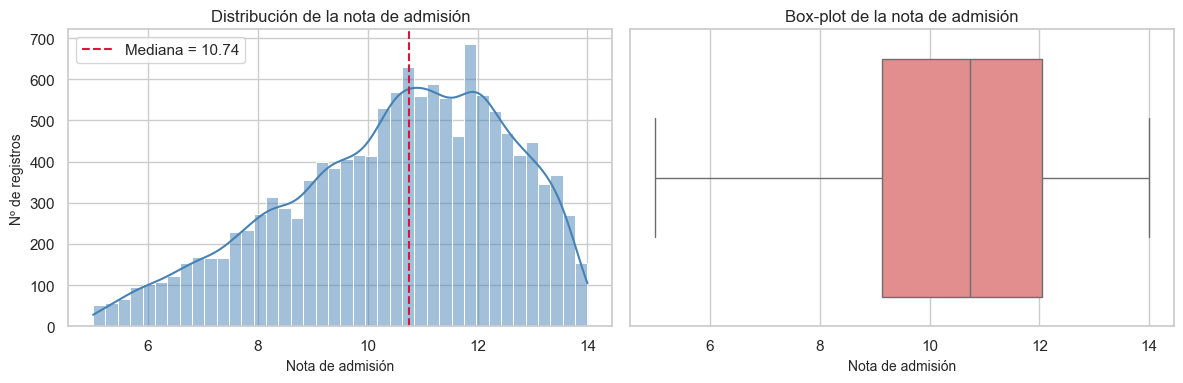

In [140]:
print("Resumen de nota_admision:")
print(df["nota_admision"].describe().round(3))
print(f"\nNulos: {df['nota_admision'].isna().sum()} / {len(df)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["nota_admision"].dropna(), bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(df["nota_admision"].median(), color="crimson", ls="--", label=f"Mediana = {df['nota_admision'].median():.2f}")
axes[0].set_title("Distribución de la nota de admisión")
axes[0].set_xlabel("Nota de admisión")
axes[0].set_ylabel("Nº de registros")
axes[0].legend()

sns.boxplot(x=df["nota_admision"].dropna(), ax=axes[1], color="lightcoral")
axes[1].set_title("Box-plot de la nota de admisión")
axes[1].set_xlabel("Nota de admisión")

plt.tight_layout()
plt.savefig("figuras/01_distribucion_nota.png", dpi=120, bbox_inches="tight")
plt.show()

La distribución es bimodal: hay una acumulación en torno a 5-7 (mínimos para acceder
con nota baja a grados de baja demanda) y otra masa principal en torno a 10-13. El
máximo es 14.

### 2.3 Variables categóricas relevantes

Examinamos algunas variables sociodemográficas y académicas clave.

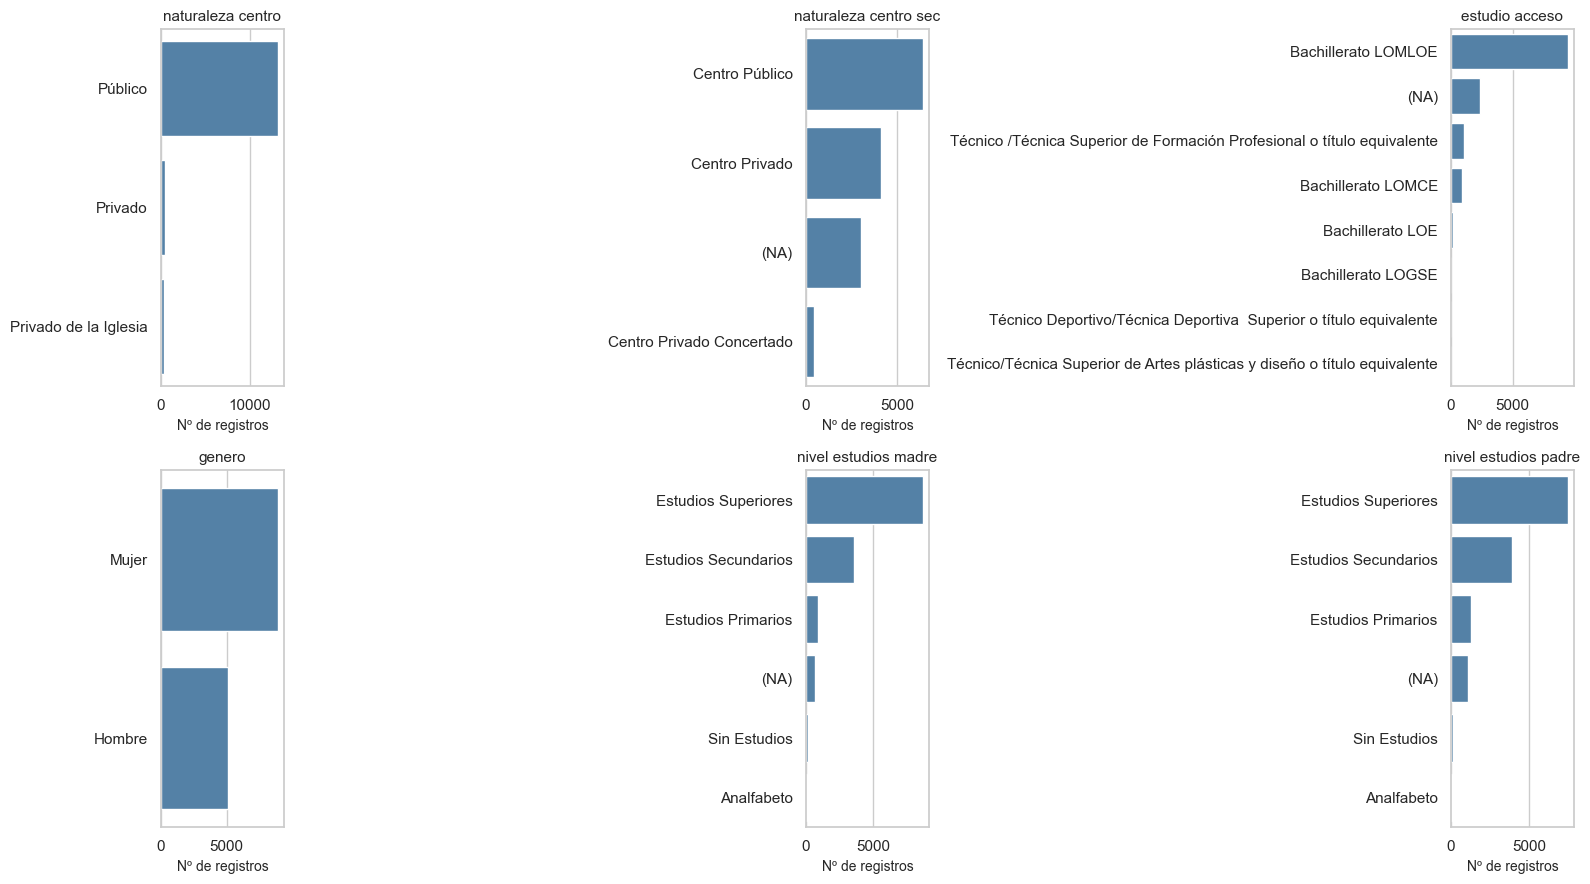

In [141]:
variables_eda = [
    "des_naturaleza_centro",
    "des_naturaleza_centro_sec",
    "des_estudio_acceso",
    "des_genero",
    "des_nivel_estudios_madre",
    "des_nivel_estudios_padre",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, variables_eda):
    counts = df[col].fillna("(NA)").value_counts().head(8)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color="steelblue")
    ax.set_title(col.replace("des_", "").replace("_", " "), fontsize=11)
    ax.set_xlabel("Nº de registros")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figuras/02_variables_categoricas.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.4 Relación entre variables y nota de admisión

¿Qué variables muestran una relación visible con la nota?

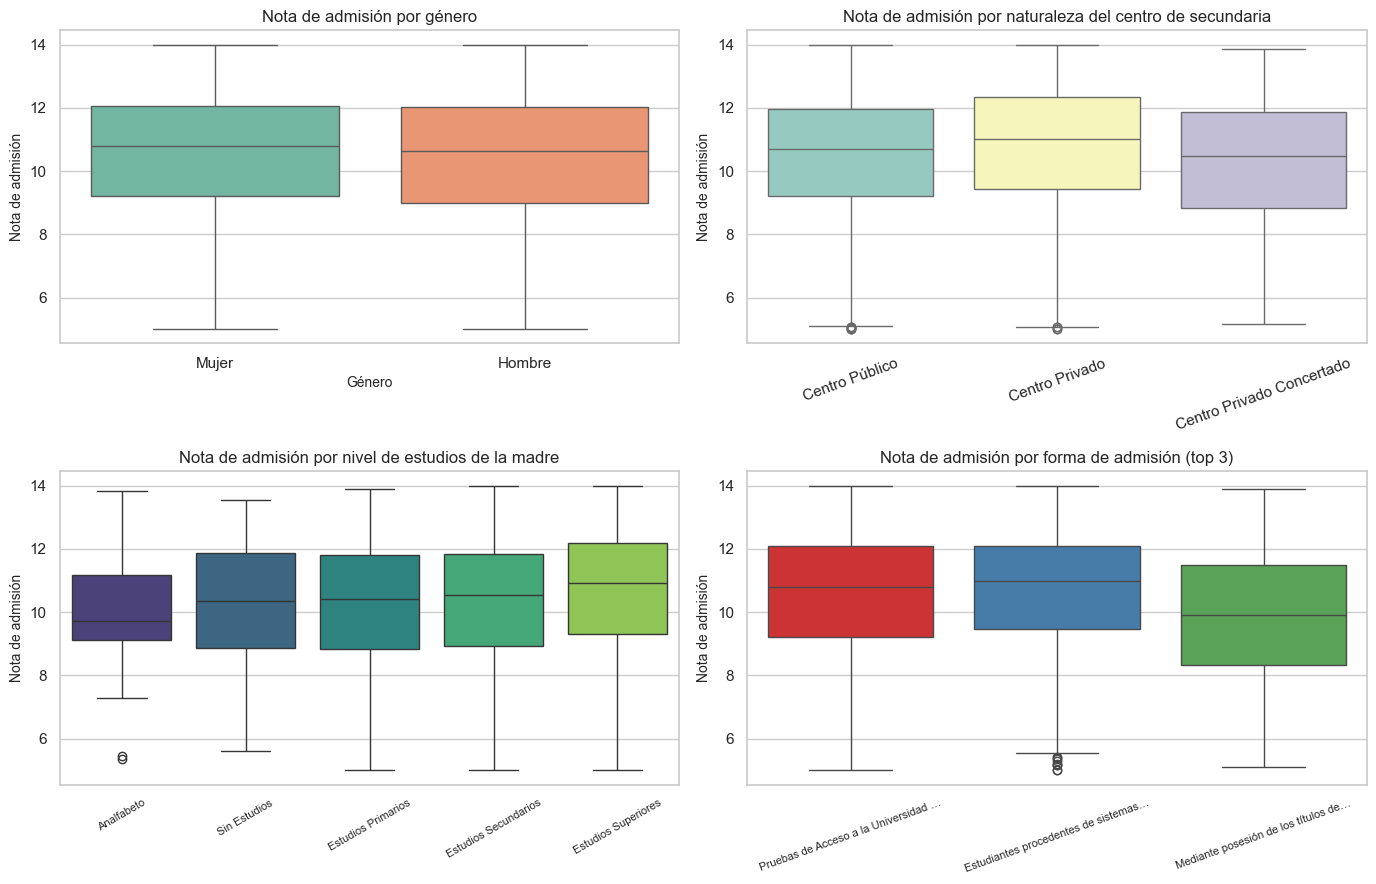

In [142]:
df_eda = df[df["nota_admision"].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Por género
sns.boxplot(data=df_eda, x="des_genero", y="nota_admision", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Nota de admisión por género")
axes[0, 0].set_xlabel("Género")
axes[0, 0].set_ylabel("Nota de admisión")

# Por tipo de centro de secundaria
orden_cs = df_eda["des_naturaleza_centro_sec"].value_counts().index[:4]
sns.boxplot(
    data=df_eda[df_eda["des_naturaleza_centro_sec"].isin(orden_cs)],
    x="des_naturaleza_centro_sec",
    y="nota_admision",
    order=orden_cs,
    ax=axes[0, 1],
    palette="Set3",
)
axes[0, 1].set_title("Nota de admisión por naturaleza del centro de secundaria")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].set_ylabel("Nota de admisión")

# Por nivel estudios de la madre
orden_madre = (
    df_eda.groupby("des_nivel_estudios_madre")["nota_admision"].median().sort_values().index
)
sns.boxplot(
    data=df_eda,
    x="des_nivel_estudios_madre",
    y="nota_admision",
    order=orden_madre,
    ax=axes[1, 0],
    palette="viridis",
)
axes[1, 0].set_title("Nota de admisión por nivel de estudios de la madre")
axes[1, 0].set_xlabel("")
axes[1, 0].tick_params(axis="x", rotation=30, labelsize=8)
axes[1, 0].set_ylabel("Nota de admisión")

# Por forma de admisión (top categorías)
top_fa = df_eda["des_forma_admision"].value_counts().head(3).index
df_fa = df_eda[df_eda["des_forma_admision"].isin(top_fa)].copy()
df_fa["forma_admision_corta"] = df_fa["des_forma_admision"].str.slice(0, 35) + "…"
sns.boxplot(
    data=df_fa,
    x="forma_admision_corta",
    y="nota_admision",
    ax=axes[1, 1],
    palette="Set1",
)
axes[1, 1].set_title("Nota de admisión por forma de admisión (top 3)")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=20, labelsize=8)
axes[1, 1].set_ylabel("Nota de admisión")

plt.tight_layout()
plt.savefig("figuras/03_relaciones_nota.png", dpi=120, bbox_inches="tight")
plt.show()

## Conocimientos extraidos: 
- Las mujeres muestran una **mediana de nota más alta** que los hombres, consistente con
un mayor rendimiento académico en secundaria.
- Los estudiantes procedentes de centros de secundaria **privados** y **concertados** acceden
  con notas medianas superiores a los procedentes de centros públicos.
- Hay un gradiente claro entre el **nivel educativo de la madre** y la nota mediana del
  hijo/a admitido.
- Las vías de admisión **EVAU/PAU** y **estudiantes UE** muestran distribuciones
  similares; **FP** accede con notas medias más bajas.



## 3. Selección de la variable objetivo

**Decisión: clasificación binaria — `nota_alta = 1 si nota_admision ≥ mediana`.**

### Justificación:

1. **No hay datos  de los estudiantes no admitidos.** El dataset sólo contiene estudiantes que ya
   han sido admitidos a un grado de la UCM.
2. **La nota de admisión determina la selección.** En grados con cupo limitado,
   la nota decide quién obtiene plaza. Predecir nota alta vs baja es, por lo tanto,
   predecir quién compite por las plazas más demandadas.
3. **Es más util la clasificación binaria que la regresión** por tres motivos:
   - Las técnicas XAI (especialmente SHAP) se interpretan de forma muy clara para
     clasificación binaria (cada SHAP value es la contribución a `P(clase=1)`).
   - Permite hablar de la "historia" en términos contundentes ("este perfil tiene 90%
     de probabilidad de nota alta") más útiles para el lector no técnico.
   - El umbral en la mediana garantiza clases balanceadas (~50/50), lo que evita
     ajustar `class_weight`.

     
Además para trabajar más adecuadamente, se excluyen las filas sin `nota_admision` (654 registros que entran por vías sin
   nota numérica). El modelo se entrenará sobre 13.365 registros.

In [143]:
df_model = df[df["nota_admision"].notna()].copy()
umbral = df_model["nota_admision"].median()
df_model["nota_alta"] = (df_model["nota_admision"] >= umbral).astype(int)

print(f"Umbral (mediana): {umbral:.3f}")
print(f"Tamaño: {len(df_model):,}")
print(f"Distribución de clases:")
print(df_model["nota_alta"].value_counts().rename({0: 'Nota baja', 1: 'Nota alta'}))

Umbral (mediana): 10.745
Tamaño: 13,365
Distribución de clases:
nota_alta
Nota alta    6684
Nota baja    6681
Name: count, dtype: int64


## 4. Preprocesamiento y selección de features

### 4.1 Selección de features

De las 77 columnas eliminamos:

- **Columnas constantes** (curso académico, universidad, tipo de estudio: todos son Grado en UCM 2024-25).
- **Códigos** redundantes con sus descripciones.
- **Latitudes/longitudes** (información geográfica ya contenida en provincia y país).
- **Indicadores con muy poca varianza** (`ind_curso_adaptacion`, etc.).
- **`nota_admision`** (es nuestra base para el target — habría leakage perfecto).
- **`anio_acceso_SUE`, `anio_fin_estudio_acceso`** (correlacionados con `anio_nacimiento`).

Mantenemos un conjunto rico de 15 features categóricas y 1 numérica (edad), que combinan
información académica, demográfica y socioeconómica.

In [144]:
# Variable derivada: edad al matricularse
df_model["edad"] = 2024 - df_model["anio_nacimiento"]

features_cat = [
   # "des_naturaleza_centro",            # universidad: público/privado/iglesia
    "des_comunidad_centro_sec",         # comunidad autónoma del bachillerato
    "des_naturaleza_centro_sec",        # secundaria: público/privado/concertado
    "des_estudio_acceso",               # Bachillerato LOMLOE / FP / etc.
    #"des_estudio_acceso",               # Bachillerato LOMLOE / FP / etc.
    "des_tipo_especialidad_acceso",     # itinerario (Ciencias, CCSS, Humanidades…)
    "des_forma_admision",               # EVAU, UE, FP, mayores 25…
    "des_genero",
    "des_familia_numerosa",
    "des_nivel_estudios_madre",
    "des_nivel_estudios_padre",
    "des_ocupacion_madre",
    "des_ocupacion_padre",
    "des_agregacion_paises_nacionalidad",
    "des_dedicacion",                   # tiempo completo / parcial
]
features_num = ["edad"]
target = "nota_alta"

# Imputaciones
for c in features_cat:
    df_model[c] = df_model[c].fillna("Desconocido").astype(str)
df_model["edad"] = df_model["edad"].fillna(df_model["edad"].median())

X = df_model[features_cat + features_num]
y = df_model[target]
print(f"Features categóricas: {len(features_cat)}")
print(f"Features numéricas:   {len(features_num)}")
print(f"X shape: {X.shape}   y shape: {y.shape}")

Features categóricas: 13
Features numéricas:   1
X shape: (13365, 14)   y shape: (13365,)


Inicialmente, el modelo se entrenó incluyendo las variables `des_estudios_acceso` y `des_naturaleza_centro`. Aunque ambas mejoraban el rendimiento predictivo, distorsionaban la interpretación del modelo al actuar como proxies de la nota de acceso:

- `des_estudios_acceso` captura indirectamente la nota de corte de cada titulación. Grados como Medicina concentran a estudiantes con notas muy altas, mientras que otros como Antropología tienen notas de corte mucho más bajas. 
- `des_naturaleza_centro` distingue entre facultades propias de la UCM y centros adscritos de titularidad privada. Dado que estos últimos solo exigen un cinco como nota de acceso, la variable separa de facto a los estudiantes por nota, funcionando también como un proxy.

Para que el análisis se centre en los factores socioeconómicos y de contexto del alumno —y no en variables que reintroduzcan implícitamente la nota de acceso—, se ha optado por excluir ambas del modelo final. 

### 4.2 Split train/test estratificado

Usamos 80/20 estratificado por la variable objetivo para mantener la proporción de clases.

In [145]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}   {y_train.mean():.3f} positivos")
print(f"Test:  {X_test.shape}   {y_test.mean():.3f} positivos")

Train: (10692, 14)   0.500 positivos
Test:  (2673, 14)   0.500 positivos


### 4.3 Pipeline de preprocesamiento

- **Categóricas → OneHotEncoder** con `min_frequency=30`: Se aplica codificación one-hot para transformar cada categoría en una variable binaria. El parámetro min_frequency=30 agrupa en una única categoría "infrequent" todos aquellos valores que aparecen menos de 30 veces en el conjunto de entrenamiento. Esta agrupación reduce la dimensionalidad  y mitiga el riesgo de sobreajuste sobre categorías minoritarias.
Variables numéricas → StandardScaler. Se estandarizan las variables numéricas (media 0, desviación típica 1) para igualar sus escalas. Este paso es especialmente relevante en la Regresión Logística, cuya optimización y cuyos coeficientes son sensibles a las magnitudes relativas de las features. En modelos basados en árboles, como HistGradientBoostingClassifier, el escalado no afecta al rendimiento, pero se mantiene por consistencia dentro del pipeline.


- **Numéricas → StandardScaler**: Se estandarizan las variables numéricas (media 0, desviación típica 1) para igualar sus escalas, necesario sobre todo para la Regresión Logística. No es necesaria para otros modelos pero su uso no afecta. 

Se encapsula todo en un `ColumnTransformer` dentro de un `Pipeline`, así evitamos
fugas de información entre train y test.

In [146]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False),
            features_cat,
        ),
        ("num", StandardScaler(), features_num),
    ]
)
preprocessor

ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               min_frequency=30,
                                               sparse_output=False),
                                 ['des_comunidad_centro_sec',
                                  'des_naturaleza_centro_sec',
                                  'des_estudio_acceso',
                                  'des_tipo_especialidad_acceso',
                                  'des_forma_admision', 'des_genero',
                                  'des_familia_numerosa',
                                  'des_nivel_estudios_madre',
                                  'des_nivel_estudios_padre',
                                  'des_ocupacion_madre', 'des_ocupacion_padre',
                                  'des_agregacion_paises_nacionalidad',
                                  'des_dedicacion']),
                                ('num', StandardScaler(), ['edad'])])

## 5. Entrenamiento de modelos

Comparamos tres modelos con paradigmas distintos:

| Modelo | Inductive bias | Interpretabilidad nativa |
|---|---|---|
| **Regresión Logística** | lineal en log-odds | coeficientes ↔ odds |
| **Random Forest** | árboles independientes (bagging) | importancias por impureza |
| **Histogram Gradient Boosting** | árboles aditivos secuenciales | importancias y SHAP exacto |

Seleccionamos por **AUC-ROC** porque es la métrica más robusta a desbalanceos leves
y refleja la calidad del ranking de probabilidades (que necesitaremos para SHAP).

In [147]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

modelos = {
    "Regresión Logística": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=400, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE
        )),
    ]),
    "Hist Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("clf", HistGradientBoostingClassifier(
            max_iter=500, max_depth=6, learning_rate=0.05, random_state=RANDOM_STATE
        )),
    ]),
}

In [148]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
)

resultados = {}
for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    resultados[nombre] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba),
        "pipe": pipe,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

tabla = pd.DataFrame({
    k: {m: v[m] for m in ["accuracy", "f1", "auc"]} for k, v in resultados.items()
}).T.round(4)
tabla

,accuracy,f1,auc
Regresión Logística,0.6031,0.6072,0.6489
Random Forest,0.5907,0.6051,0.6388
Hist Gradient Boosting,0.6034,0.6206,0.6404


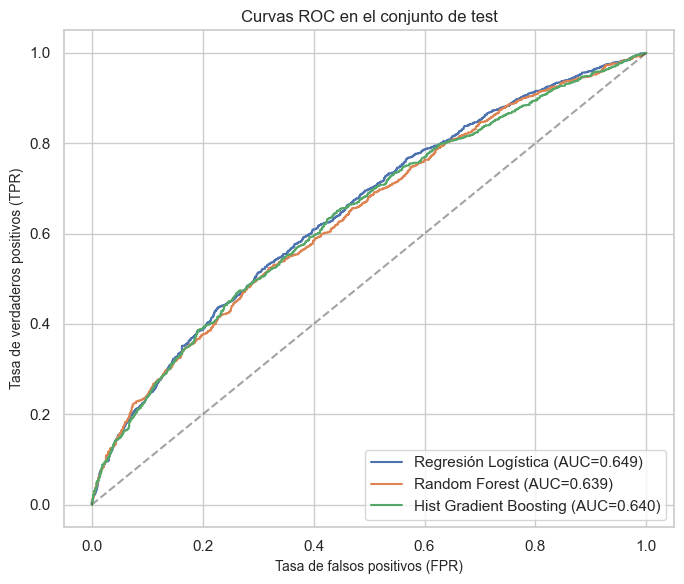

In [149]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, r in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={r['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR)")
ax.set_title("Curvas ROC en el conjunto de test")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figuras/04_curvas_roc.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.1 Selección del modelo final

La **Regresión Logística** obtiene un AUC ligeramente superior (véase tabla), pero el
**Histogram Gradient Boosting** está a muy poca distancia y aporta dos
ventajas decisivas para nuestra historia XAI:

1. **Captura efectos no lineales e interacciones** entre titulación, género y centro
   de secundaria — exactamente el tipo de patrones que queremos descubrir.
2. **Permite SHAP TreeExplainer**, que es exacto (no aproximado) y computacionalmente
   eficiente sobre árboles. Las explicaciones serán más fiables que las de un
   `LinearExplainer` sobre un modelo lineal.

Por estos motivos, escogemos **Hist Gradient Boosting** como modelo final.



El modelo alcanza un AUC de 0.6404, un F1 de 0.6206 y una accuracy de 0.6034: cifras superiores al azar, pero modestas en términos absolutos. Este rendimiento se ve afectado por la decisión de excluir las variables que actuaban como proxies de la nota (`des_estudios_acceso` y `es_naturaleza_centro`), por lo que el modelo se apoya exclusivamente en factores sociodemográficos y de contexto, cuya capacidad predictiva sobre la nota de admisión es limitada al no contar con datos de los no admitidos. Que el rendimiento siga estando por encima del azar es un hallazgo relevante: indica que el entorno socioeconómico aporta señal real sobre la nota de acceso, sin llegar a determinarla. En este contexto, el objetivo no es maximizar la precisión predictiva, sino disponer de un modelo suficientemente discriminativo como para que sus explicaciones SHAP sean informativas. Continuar con el análisis está justificado porque la pregunta de investigación es explicativa, no predictiva: interesa entender qué factores contextuales mueven la predicción y en qué dirección, más que anticipar la nota de cada alumno individual.


In [150]:
mejor_nombre = "Hist Gradient Boosting"
mejor_pipe = resultados[mejor_nombre]["pipe"]
print(f"Modelo final: {mejor_nombre}")
print(f"AUC: {resultados[mejor_nombre]['auc']:.4f}")
print(f"F1:  {resultados[mejor_nombre]['f1']:.4f}")
print(f"Accuracy: {resultados[mejor_nombre]['accuracy']:.4f}")

y_pred_best = resultados[mejor_nombre]["y_pred"]
y_proba_best = resultados[mejor_nombre]["y_proba"]
print("\n=== Classification report ===")
print(classification_report(y_test, y_pred_best, target_names=["Nota baja", "Nota alta"]))

Modelo final: Hist Gradient Boosting
AUC: 0.6404
F1:  0.6206
Accuracy: 0.6034

=== Classification report ===
              precision    recall  f1-score   support

   Nota baja       0.61      0.56      0.58      1336
   Nota alta       0.60      0.65      0.62      1337

    accuracy                           0.60      2673
   macro avg       0.60      0.60      0.60      2673
weighted avg       0.60      0.60      0.60      2673



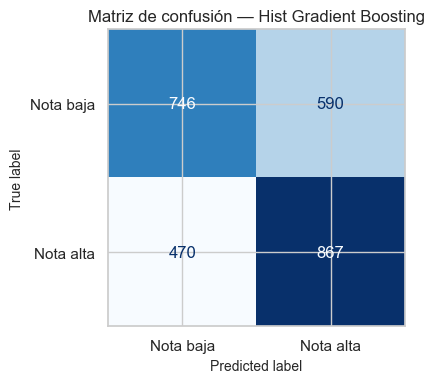

In [151]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=["Nota baja", "Nota alta"]).plot(
    ax=ax, cmap="Blues", values_format="d", colorbar=False
)
ax.set_title(f"Matriz de confusión — {mejor_nombre}")
plt.tight_layout()
plt.savefig("figuras/05_matriz_confusion.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Explicaciones XAI: SHAP

Se aplica **`TreeExplainer`** sobre el `HistGradientBoostingClassifier`, que calcula los valores de Shapley de forma exacta en el espacio de **log-odds** de la clase positiva.

El análisis se estructura en tres niveles:

- **Shap bar plot** (`mean(|SHAP|)`): ranking de variables que más mueven la predicción.
- **Beeswarm**: dirección y dispersión del efecto de cada feature.
- **Waterfall**: efecto detallado sobre variables de interés sociológico (género, estudios de los progenitores, comunidad de procedencia).

El objetivo es **traducir el comportamiento del modelo en una narrativa** sobre qué perfiles socioeconómicos eleva o penaliza. 

In [152]:
import shap

preprocessor_fit = mejor_pipe.named_steps["prep"]
clf = mejor_pipe.named_steps["clf"]
feature_names = preprocessor_fit.get_feature_names_out()
# Limpiamos los nombres para que sean más legibles en los gráficos
feature_names_clean = [
    n.replace("cat__", "").replace("num__", "")
    for n in feature_names
]

X_train_t = preprocessor_fit.transform(X_train)
X_test_t = preprocessor_fit.transform(X_test)
print(f"Features tras OHE: {len(feature_names_clean)}")
print("Primeras 5:", feature_names_clean[:5])

Features tras OHE: 101
Primeras 5: ['des_comunidad_centro_sec_Andalucía', 'des_comunidad_centro_sec_Aragón', 'des_comunidad_centro_sec_Asturias', 'des_comunidad_centro_sec_Canarias', 'des_comunidad_centro_sec_Cantabria']


In [153]:
# Muestreamos 800 ejemplos del test para SHAP (suficiente para gráficos globales y
# manejable en memoria)
rng = np.random.default_rng(RANDOM_STATE)
idx_sample = rng.choice(len(X_test_t), size=min(800, len(X_test_t)), replace=False)
X_test_sample = X_test_t[idx_sample]

explainer = shap.TreeExplainer(clf)
shap_values_raw = explainer.shap_values(X_test_sample)

# Para HistGradientBoosting binario, shap_values devuelve un array (n, m) con los
# valores para la clase positiva (log-odds). Lo manejamos genéricamente:
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
    expected_value = explainer.expected_value[1]
elif shap_values_raw.ndim == 3:
    shap_values = shap_values_raw[:, :, 1]
    expected_value = explainer.expected_value[1]
else:
    shap_values = shap_values_raw
    expected_value = explainer.expected_value

print(f"shape SHAP: {shap_values.shape}")
print(f"Valor esperado del modelo (log-odds base): {float(np.asarray(expected_value).squeeze()):.4f}")

shape SHAP: (800, 101)
Valor esperado del modelo (log-odds base): 0.0025


### 6.1 Importancia global de features

Se promedia  el valor absoluto de los SHAP para cada feature: devolviendo una medida de
cuánto contribuye esa feature, en magnitud, a la predicción.


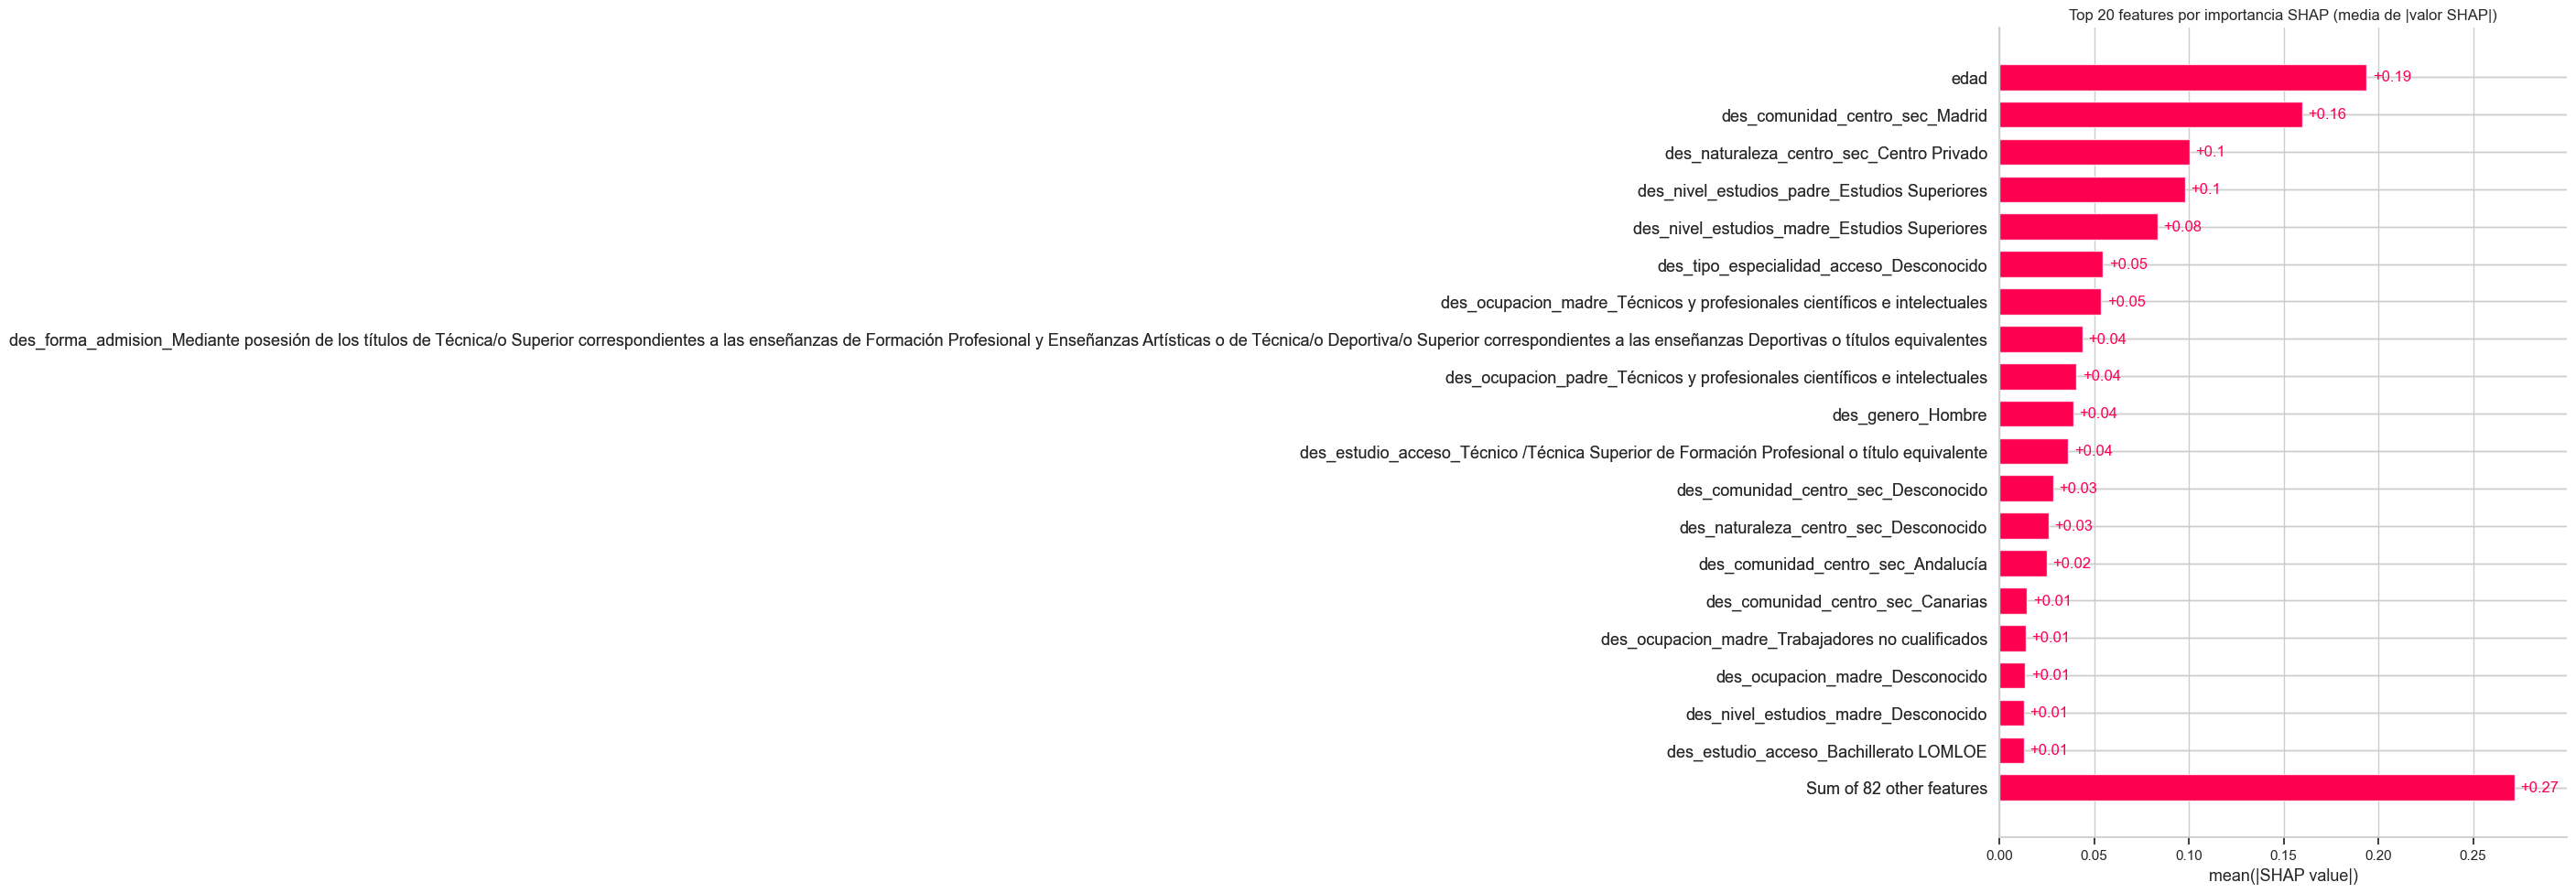

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Bar plot nativo de SHAP (top 20 features post-OHE)
# ============================================================

# Crear el objeto Explanation necesario para shap.plots.bar
shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_t,                       # datos transformados que usaste en el explainer
    feature_names=feature_names_clean,
)

shap.plots.bar(shap_exp, max_display=20, show=False)
plt.title("Top 20 features por importancia SHAP (media de |valor SHAP|)")
plt.tight_layout()
plt.savefig("figuras/06_shap_bar_features.png", dpi=120, bbox_inches="tight")
plt.show()

La variable más influyente es edad (+0.19), seguida de cerca por características del centro de secundaria de procedencia: la comunidad autónoma donde se cursó —destacando Madrid (+0.16) y, con menor peso, Andalucía (+0.02) y Canarias (+0.01)— y su titularidad (Centro Privado +0.10). Este bloque sugiere que el contexto territorial de origen del estudiante antes de llegar a la universidad pesa mucho en la predicción.

El segundo bloque corresponde al capital sociocultural familiar: los estudios superiores del padre (+0.10) y de la madre (+0.08), junto con las ocupaciones técnico-científicas de ambos progenitores (+0.05 y +0.04, respectivamente). El que estudios y ocupación aparezcan con magnitudes similares en ambos progenitores indica que el modelo no se apoya especialmente en ninguna de las figuras, ni en el padre ni en la madre. 

Un tercer bloque, de menor peso, recoge variables del propio alumno y su vía de acceso: el género (Hombre +0.04), el tipo de especialidad y la forma de admisión. Estas variables influyen, pero con magnitudes claramente inferiores a las dos primeras categorías.

### 6.2 Resumen SHAP (beeswarm)

El beeswarm muestra, para las 20 features más importantes, la distribución de los SHAP
de cada observación coloreada por el valor de la feature (rojo = feature presente,
azul = ausente, dado que casi todo es one-hot binario).

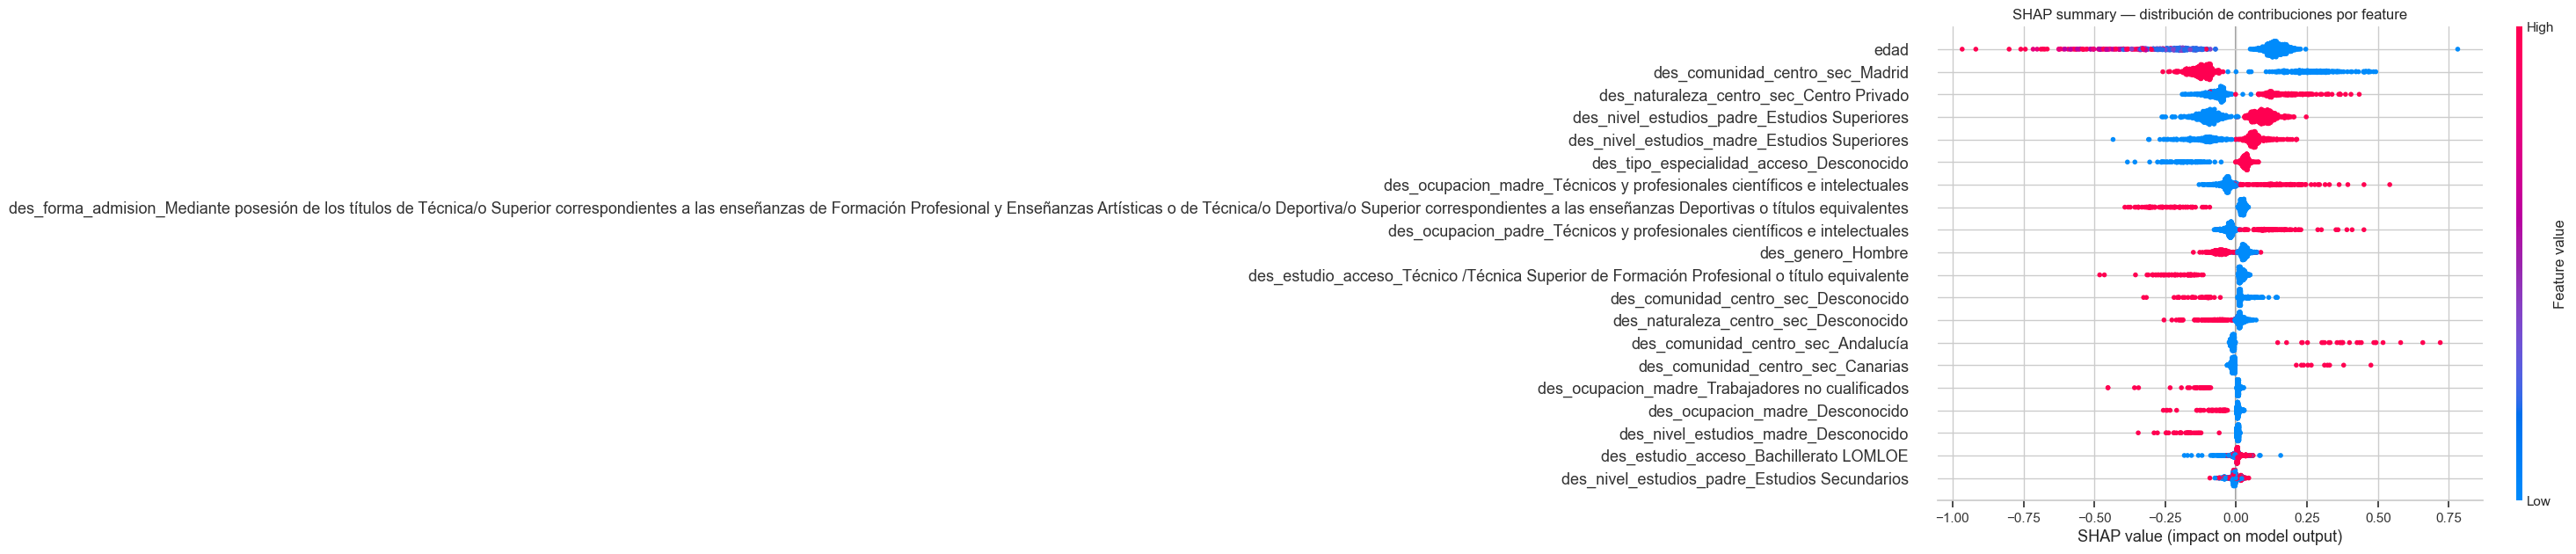

In [155]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names_clean,
    max_display=20,
    show=False,
)
plt.gcf().set_size_inches(10, 7)
plt.title("SHAP summary — distribución de contribuciones por feature")
plt.tight_layout()
plt.savefig("figuras/07_shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

# Análisis del SHAP beeswarm

El grafico nos muestra, en el eje horizontal, como ha empujado y en que sentido (menor o mayor que cero) cada variable la predicción de un estudiante concreto (todos dispuestos sobre el eje horizontal). El color representa donde se encuentra realmente el estudiante. 

## Lectura por bloques

**Trayectoria del estudiante.** La variable `edad` muestra el patrón más nítido: los puntos rojos (estudiantes mayores) se sitúan claramente a la izquierda, con una cola que llega a −1.0, mientras que los azules (más jóvenes) ocupan la zona derecha. De esta manera, una mayor edad contribuye negativamente a la predicción, lo que es coherente con que las trayectorias regulares (18–19 años) se asocien a mejores notas y las edades altas a vías de acceso alternativas.

**Contexto territorial e institucional.** En `des_comunidad_centro_sec_Madrid`, los puntos rojos (estudiantes de Madrid) se sitúan a la izquierda del 0 y los azules (de otras CCAA) a la derecha: proceder de Madrid empuja la predicción hacia "nota baja". Este resultado, aparentemente contraintuitivo, se puede explicar por varios motivos. En primer lugar, los estudiantes procedentes de otras CCAA constituyen un posible filtro adicional, mientras que en Madrid acceden estudiantes con todo tipo d erendimiento. Además, la potencial ventaja socieconomica madrileña puede quedar capturada ya por otras varibales (centro privado, estudios de los padres, etc). Destaca que en el caso de Andalucía y Canarias estos si empujan la predicción hacía arriba: lo que podría añadir otro enfoque en la disyuntiva politica mencionada en la introducción: la dificultad de la prueba de acceso por regiones, donde Madrid tiene la reputación de ser más díficil, frente precisamente a comunidades como Canarias y Andalucía que tienen la reputación contraria. 

**Capital sociocultural familiar.** Los **estudios superiores** del padre y de la madre empujan claramente al alza (rojos a la derecha en ambas variables), y lo mismo hacen las ocupaciones técnico-científicas de ambos progenitores. En el extremo opuesto, `des_ocupacion_madre_Trabajadores no cualificados` muestra rojos a la izquierda: ocupaciones menos cualificadas en el hogar penalizan la predicción. Estudios del padre como `Secundarios` aparecen con un efecto pequeño y disperso.

**Género.** En `des_genero_Hombre`, los puntos rojos (hombres) se concentran a la izquierda y los azules (mujeres) a la derecha. Ser hombre reduce la predicción de nota alta, lo que coincide con la intuición de un mayor rendimiento acedmico femenino durante la educación secundaria. 

**Categorías "Desconocido".** `tipo_especialidad_acceso_Desconocido`, `comunidad_centro_sec_Desconocido`, `naturaleza_centro_sec_Desconocido`, `ocupacion_madre_Desconocido` y `nivel_estudios_madre_Desconocido` muestran todos los rojos a la izquierda: la falta de información penaliza sistemáticamente la predicción. El modelo aprende que la ausencia de dato es, en sí misma, una señal negativa —probablemente porque correlaciona con perfiles cuya información está menos completa.

**Vía de acceso.** Las variables del proceso de admisión (`des_forma_admision_Mediante posesión de títulos…`, `des_estudio_acceso_Técnico…`, `des_estudio_acceso_Bachillerato LOMLOE`) muestran efectos negativos cuando están presentes, aunque con magnitudes menores. Estas vías no convencionales penalizan moderadamente la predicción.


De esta manera, el gráfico dibuja un perfil tipo: estudiante joven, mujer, de centro de secundaria privado, con ambos progenitores con estudios superiores y ocupaciones técnico-científicas, y con información administrativa completa. El perfil opuesto —mayor edad, hombre, ocupaciones no cualificadas, datos faltantes— recibe empujes a la baja.


Lo relevante no es solo el efecto de cada variable, sino que todos los efectos van en la misma dirección: el modelo, sin que se le haya enseñado explícitamente, ha aprendido que el contexto socioeconómico y territorial del estudiante predice su nota de admisión. Esta coherencia interna es precisamente lo que da peso explicativo al análisis y sustenta la hipótesis del trabajo. 

### 6.3 Análisis de dependencia: género y nivel educativo de la madre

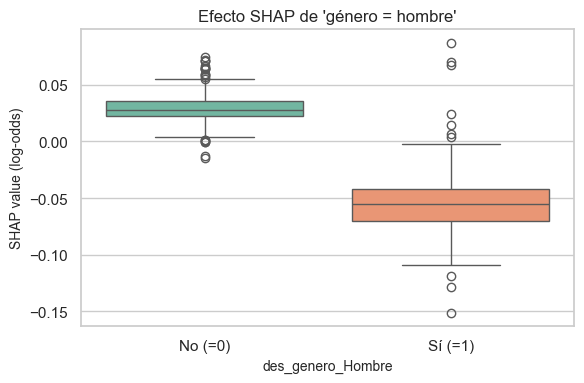

In [156]:
def shap_dependence_categorical(feature_name, title):
    if feature_name not in feature_names_clean:
        print(f"Feature {feature_name} no encontrada"); return
    idx = feature_names_clean.index(feature_name)
    vals = X_test_sample[:, idx]
    shp = shap_values[:, idx]
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(x=vals.astype(int), y=shp, ax=ax, palette="Set2")
    ax.set_xticklabels(["No (=0)", "Sí (=1)"])
    ax.set_xlabel(feature_name)
    ax.set_ylabel("SHAP value (log-odds)")
    ax.set_title(title)
    plt.tight_layout()
    return fig

f = shap_dependence_categorical(
    "des_genero_Hombre",
    "Efecto SHAP de 'género = hombre'"
)
plt.savefig("figuras/08_shap_dep_genero.png", dpi=120, bbox_inches="tight")
plt.show()

El gráfico muestra una diferencia clara en la contribución SHAP según el género. Para la categoría mujer los valores SHAP son mayoritariamente positivos, lo que indica que esta condición tiende a aumentar ligeramente la predicción de una nota de admisión más alta. En cambio, para la categoría “Sí (=1)” los valores SHAP se concentran en valores negativos, sugiriendo que ser hombre reduce la predicción del modelo respecto a la nota esperada. Además, la separación entre ambas distribuciones es bastante marcada y con poca superposición, lo que indica que el género tiene un efecto relativamente consistente dentro del modelo.

Categorías disponibles para nivel de estudios de la madre:
 - des_nivel_estudios_madre_Analfabeto
 - des_nivel_estudios_madre_Desconocido
 - des_nivel_estudios_madre_Estudios Primarios
 - des_nivel_estudios_madre_Estudios Secundarios
 - des_nivel_estudios_madre_Estudios Superiores
 - des_nivel_estudios_madre_Sin Estudios


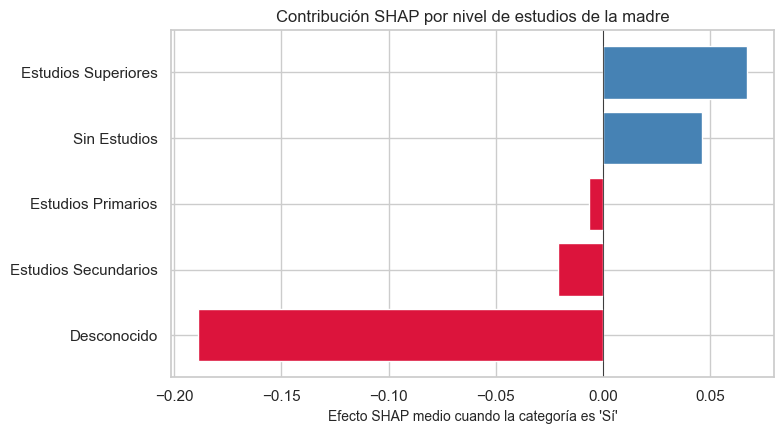

,categoria,n,shap_medio
0,Desconocido,30,-0.188708
2,Estudios Secundarios,197,-0.020803
1,Estudios Primarios,54,-0.006599
4,Sin Estudios,8,0.046145
3,Estudios Superiores,509,0.067028


In [157]:
# Se recopilan las categorías de nivel de estudios de la madre para analizarlas
candidatos_madre = [n for n in feature_names_clean if "nivel_estudios_madre" in n]
print("Categorías disponibles para nivel de estudios de la madre:")
for c in candidatos_madre:
    print(" -", c)

# Se muestra el efecto SHAP medio por nivel educativo de la madre, solo para categorías con al menos 5 ejemplos en el test
shap_dep_madre = []
for c in candidatos_madre:
    idx = feature_names_clean.index(c)
    mask = X_test_sample[:, idx] == 1
    if mask.sum() >= 5:
        shap_dep_madre.append({
            "categoria": c.replace("des_nivel_estudios_madre_", ""),
            "n": int(mask.sum()),
            "shap_medio": float(shap_values[mask, idx].mean()),
        })
df_dep_madre = pd.DataFrame(shap_dep_madre).sort_values("shap_medio")

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["crimson" if v < 0 else "steelblue" for v in df_dep_madre["shap_medio"]]
ax.barh(df_dep_madre["categoria"], df_dep_madre["shap_medio"], color=colors)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Efecto SHAP medio cuando la categoría es 'Sí'")
ax.set_title("Contribución SHAP por nivel de estudios de la madre")
plt.tight_layout()
plt.savefig("figuras/09_shap_dep_madre.png", dpi=120, bbox_inches="tight")
plt.show()
df_dep_madre

Se calcula un gráfico pormenorizado para el nivel de esutios de la madre, una de las variables potencialmente sensibles en el ámbito socioeconómico. El gráfico muestra que, en general, las categorías “Estudios Superiores” y “Sin Estudios” de la madre presentan una contribución positiva sobre la predicción de la nota de admisión. Resulta especialmente llamativo el caso de “Sin Estudios”, ya que, de forma aparentemente paradójica, también empuja la predicción al alza; sin embargo, este comportamiento podría explicarse por el reducido tamaño de la categoría (n=8), lo que puede generar estimaciones menos estables. Por otro lado, las categorías “Estudios Secundarios”, “Estudios Primarios” y “Desconocido” muestran contribuciones negativas, reduciendo la predicción realizada por el modelo.

## 7. XAI Stories: explicaciones locales con SHAP y LIME

Ahora pasamos del "qué importa en general" al "por qué este estudiante concreto fue
clasificado así". Seleccionamos **tres casos representativos**:

- **Story 1 — Prototipo:** una predicción de nota alta con alta
  confianza que el modelo acierta. Queremos ver qué factores la sostienen.
- **Story 2 — Crítca:** una predicción que el modelo falla. La explicación
  XAI nos permite diagnosticar **por qué el modelo se equivoca**.
- **Story 3 — Caso limite:** una predicción con probabilidad cercana a 0.5. ¿Qué
  variables están "tirando" de cada lado?

Para cada uno, se mostrará el perfil del estudiante, la explicación SHAP local y la
explicación LIME. La comparación entre las dos técnicas también es interesante: SHAP
da una descomposición global exacta, LIME un modelo lineal local aproximado.

In [158]:
# Se indexa para poder seleccionar casos sobre el test
y_test_arr = y_test.values
proba_test = y_proba_best

# Caso correcto: predice nota alta con alta probabilidad y acierta
mask_correct_high = (y_test_arr == 1) & (np.array(y_pred_best) == 1) & (proba_test > 0.90)
idx_correct = int(np.where(mask_correct_high)[0][0])

# Caso incorrecto: predicción equivocada con confianza alta (>0.7 fuera de su clase real)
mask_wrong = (y_test_arr != np.array(y_pred_best))
idx_wrong_candidates = np.where(mask_wrong & (np.abs(proba_test - 0.5) > 0.25))[0]
idx_wrong = int(idx_wrong_candidates[0])

# Caso limite: proba ≈ 0.5
idx_border = int(np.argsort(np.abs(proba_test - 0.5))[0])

print(f"Caso correcto:    idx={idx_correct}   y_real=Alta   y_pred=Alta   P(alta)={proba_test[idx_correct]:.3f}")
print(f"Caso incorrecto:  idx={idx_wrong}     y_real={'Alta' if y_test_arr[idx_wrong]==1 else 'Baja'}   "
      f"y_pred={'Alta' if y_pred_best[idx_wrong]==1 else 'Baja'}   P(alta)={proba_test[idx_wrong]:.3f}")
print(f"Caso limite:  idx={idx_border}    y_real={'Alta' if y_test_arr[idx_border]==1 else 'Baja'}   "
      f"y_pred={'Alta' if y_pred_best[idx_border]==1 else 'Baja'}   P(alta)={proba_test[idx_border]:.3f}")

Caso correcto:    idx=19   y_real=Alta   y_pred=Alta   P(alta)=0.924
Caso incorrecto:  idx=21     y_real=Alta   y_pred=Baja   P(alta)=0.217
Caso limite:  idx=1670    y_real=Alta   y_pred=Alta   P(alta)=0.500


In [159]:
def perfil_estudiante(idx_pos):
    fila = X_test.iloc[idx_pos]
    nota_real = df_model.loc[X_test.iloc[idx_pos].name, "nota_admision"]
    info = {
        "Centro secundaria": fila["des_naturaleza_centro_sec"],
        "Comunidad sec.": fila["des_comunidad_centro_sec"],
        "Estudio acceso": fila["des_estudio_acceso"],
        "Forma admisión": fila["des_forma_admision"][:60] + ("…" if len(fila["des_forma_admision"]) > 60 else ""),
        "Género": fila["des_genero"],
        "Nivel estudios madre": fila["des_nivel_estudios_madre"],
        "Nivel estudios padre": fila["des_nivel_estudios_padre"],
        "Edad": int(fila["edad"]),
        "Nota real": round(nota_real, 2),
        "Clase real": "Alta" if y_test.iloc[idx_pos] == 1 else "Baja",
        "P(alta) modelo": round(float(proba_test[idx_pos]), 3),
    }
    return pd.Series(info, name=f"Estudiante (idx={idx_pos})")

In [160]:
# Calculamos SHAP completo para los tres casos (sobre el modelo, no la muestra)
casos_idx = [idx_correct, idx_wrong, idx_border]
casos_t = X_test_t[casos_idx]
shap_casos_raw = explainer.shap_values(casos_t)
if isinstance(shap_casos_raw, list):
    shap_casos = shap_casos_raw[1]
elif shap_casos_raw.ndim == 3:
    shap_casos = shap_casos_raw[:, :, 1]
else:
    shap_casos = shap_casos_raw
print("SHAP casos shape:", shap_casos.shape)

SHAP casos shape: (3, 101)


### 7.1. Story 1 — Caso correcto: un estudiante con perfil de alto rendimiento


In [161]:
perfil_estudiante(idx_correct)

Centro secundaria                                          Centro Privado
Comunidad sec.                                                   Canarias
Estudio acceso                                        Bachillerato LOMLOE
Forma admisión          Pruebas de Acceso a la Universidad (EVAU, PAU ...
Género                                                             Hombre
Nivel estudios madre                                  Estudios Superiores
Nivel estudios padre                                  Estudios Superiores
Edad                                                                   18
Nota real                                                           12.89
Clase real                                                           Alta
P(alta) modelo                                                      0.924
Name: Estudiante (idx=19), dtype: object

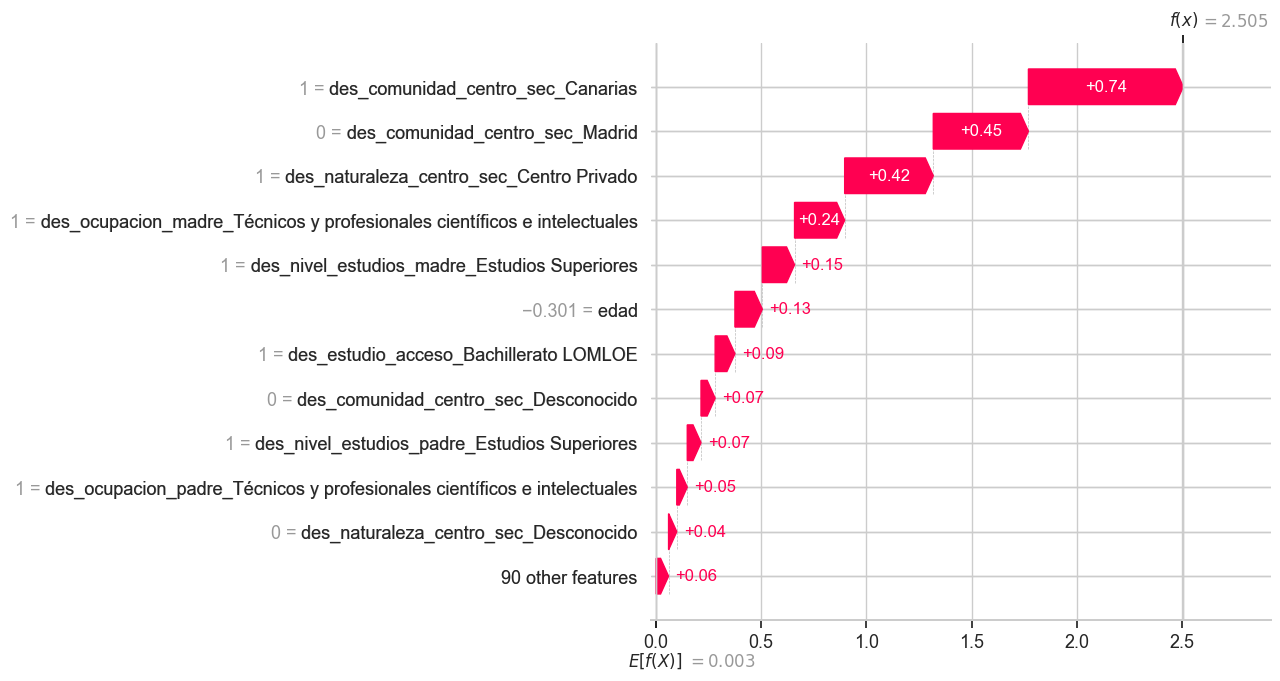

<Figure size 640x480 with 0 Axes>

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_casos[0],
        base_values=float(np.asarray(expected_value).squeeze()),
        data=X_test_t[idx_correct],
        feature_names=feature_names_clean,
    ),
    max_display=12,
    show=True,
)
plt.savefig("figuras/10_story1_shap_waterfall.png", dpi=120, bbox_inches="tight")

#### **Narrativa caso 1:**

El gráfico waterfall del caso 1 muestra una predicción de nota alta con f(x) = 2.505 log-odds
partiendo de un valor base casi nulo (0.003), lo que significa que prácticamente todo el peso
predictivo proviene del perfil concreto del estudiante. El factor más determinante es proceder
de Canarias (+0.74), seguido de **no** ser de Madrid (+0.45, efecto de ausencia) y haber
cursado la secundaria en un centro privado (+0.42). A estos se suman el capital educativo
familiar —madre con ocupación técnico-científica (+0.24) y estudios superiores (+0.15),
padre con el mismo perfil (+0.05 y +0.07)— y una edad ligeramente por debajo de la media
(−0.301 estandarizado, +0.13). Todos los efectos van en la misma dirección: no hay ninguna
variable que empuje hacia "nota baja", lo que explica la alta confianza del modelo en su
predicción. Este perfil —joven, de Canarias, centro privado, progenitores con formación
superior— ejemplifica el arquetipo que el modelo identifica como de alto rendimiento académico.

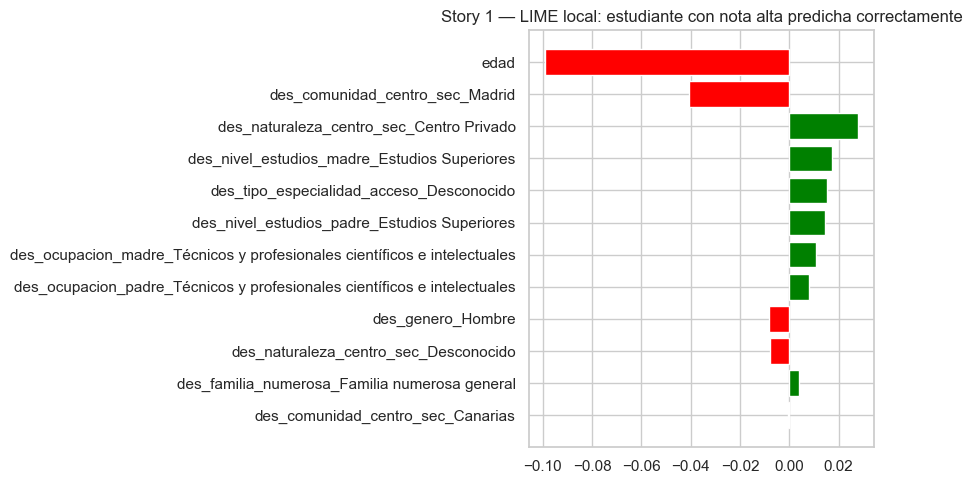

In [163]:
# LIME para el mismo caso
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_t),
    feature_names=list(feature_names_clean),
    class_names=["Nota baja", "Nota alta"],
    discretize_continuous=False,
    random_state=RANDOM_STATE,
    mode="classification",
)

def predict_fn(arr):
    return clf.predict_proba(arr)

exp1 = lime_explainer.explain_instance(
    data_row=np.array(X_test_t[idx_correct]),
    predict_fn=predict_fn,
    num_features=12,
)
fig = exp1.as_pyplot_figure()
fig.set_size_inches(9, 5)
plt.title("Story 1 — LIME local: estudiante con nota alta predicha correctamente")
plt.tight_layout()
plt.savefig("figuras/11_story1_lime.png", dpi=120, bbox_inches="tight")
plt.show()

#### **Comparación SHAP vs LIME:** 
El gráfico de LIME coincide parcialmente con el análisis SHAP, pero también muestra diferencias importantes derivadas de cómo cada técnica explica la predicción. Ambas metodologías identifican como factores positivos estudiar en un centro privado, tener padres con estudios superiores y ocupaciones técnicas o profesionales cualificadas, lo que refuerza la idea de que el contexto socioeducativo del estudiante favorece una predicción alta. Sin embargo, LIME introduce algunas discrepancias relevantes: por ejemplo, la variable “Madrid” aparece ahora con contribución negativa, mientras que en SHAP la ausencia de Madrid generaba un efecto positivo. Además, la edad se convierte en el factor negativo más importante en LIME, algo que no destacaba tanto en SHAP y algo extraño teniendo en cuenta los 18 años del caso. También llama la atención que “Canarias”, que en SHAP era la variable más influyente, apenas tiene peso en la explicación local de LIME. Esto refleja la diferencia conceptual entre ambas técnicas: SHAP descompone exactamente la contribución del modelo completo, mientras que LIME aproxima el comportamiento del modelo mediante una regresión lineal local, pudiendo asignar pesos distintos según el vecindario utilizado para generar la explicación.

### 7.2. Story 2 — Crítica: cuando el modelo se equivoca

In [164]:
perfil_estudiante(idx_wrong)

Centro secundaria                                             Desconocido
Comunidad sec.                                                Desconocido
Estudio acceso          Técnico /Técnica Superior de Formación Profesi...
Forma admisión          Pruebas de Acceso a la Universidad (EVAU, PAU ...
Género                                                             Hombre
Nivel estudios madre                                  Estudios Superiores
Nivel estudios padre                                 Estudios Secundarios
Edad                                                                   21
Nota real                                                           13.82
Clase real                                                           Alta
P(alta) modelo                                                      0.217
Name: Estudiante (idx=21), dtype: object

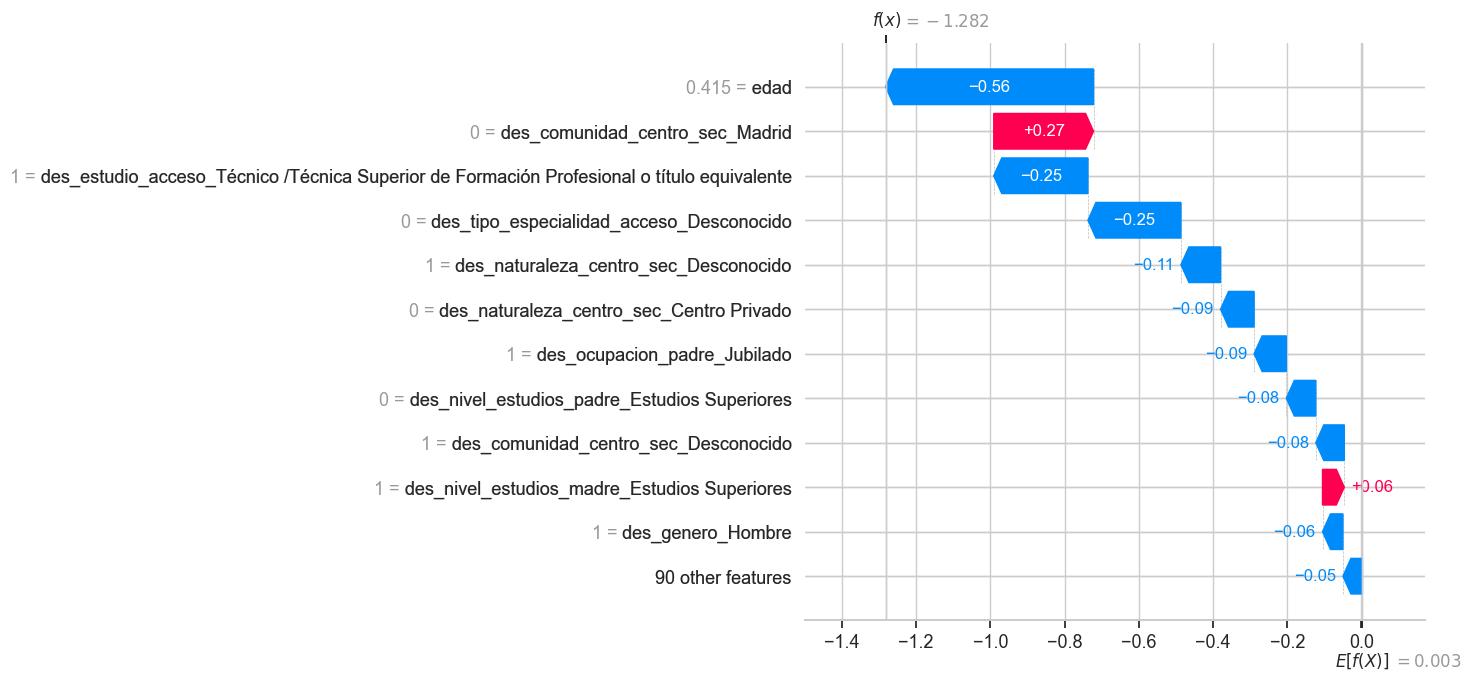

<Figure size 640x480 with 0 Axes>

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_casos[1],
        base_values=float(np.asarray(expected_value).squeeze()),
        data=X_test_t[idx_wrong],
        feature_names=feature_names_clean,
    ),
    max_display=12,
    show=True,
)
plt.savefig("figuras/12_story2_shap_waterfall.png", dpi=120, bbox_inches="tight")

 #### **Narrativa caso 2:**

El gráfico waterfall del caso 2 (predicción incorrecta) muestra una predicción final de f(x) = −1.282 log-odds,
equivalente a una probabilidad de nota alta de apenas el 22% — el modelo predice "nota baja" con alta confianza
cuando en realidad el estudiante tenía nota alta. Partiendo del valor base E[f(X)] = 0.003, casi todas las
contribuciones empujan en dirección negativa: la edad (−0.301) es el factor más penalizador
(−0.56), seguida de la especialidad de acceso desconocida (−0.25) y la ausencia de información clara sobre
la vía de acceso (−0.25). A estos se suman efectos menores pero acumulativos: naturaleza del centro
desconocida (−0.11), centro privado (−0.09), padre sin ocupación técnica ni estudios superiores (−0.08 cada
uno), madre sin estudios superiores (−0.08), ser hombre (−0.06) y el resto de features (−0.05). El único
factor que empuja hacia nota alta es proceder de Madrid (+0.27), pero no es suficiente para contrarrestar
la suma de señales negativas. El error del modelo se explica por la poca concreción en el perfil, al haber muchos datos desconocidos que arrastran sistemáticamente la predicción hacia "nota baja"
aunque el estudiante haya obtenido una nota real alta.

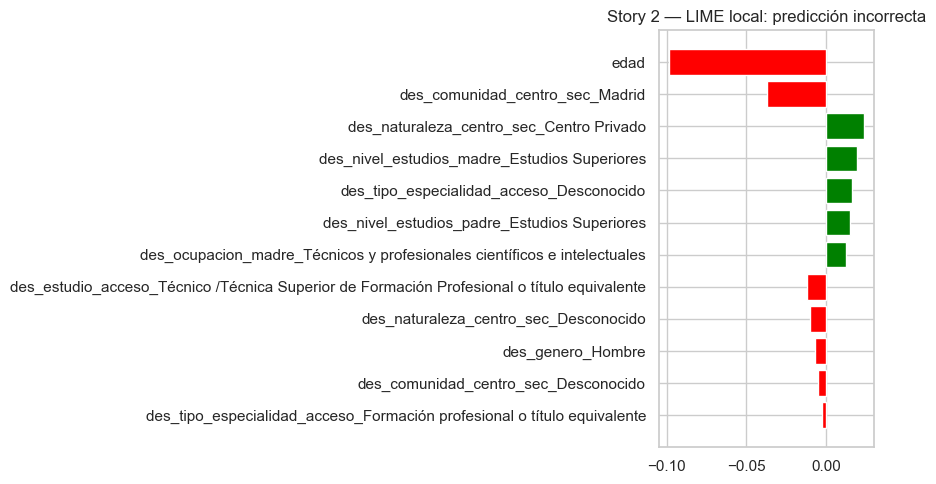

In [166]:
exp2 = lime_explainer.explain_instance(
    data_row=np.array(X_test_t[idx_wrong]),
    predict_fn=predict_fn,
    num_features=12,
)
fig = exp2.as_pyplot_figure()
fig.set_size_inches(9, 5)
plt.title("Story 2 — LIME local: predicción incorrecta")
plt.tight_layout()
plt.savefig("figuras/13_story2_lime.png", dpi=120, bbox_inches="tight")
plt.show()

#### **Comparación SHAP vs LIME (Story 2):** 

Ambas técnicas identifican la edad y haber estudiado en Madrid como las variables más influyentes, y ambas coinciden en que la edad
penaliza fuertemente la predicción mientras que Madrid la empuja al alza. También coinciden en que
`des_tipo_especialidad_acceso_Desconocido` y `des_naturaleza_centro_sec_Desconocido` penalizan, y en
el efecto negativo de ser hombre. Las diferencias son más reveladoras: LIME asigna a haber estudiado en un centro privado y al nivel de estudios de los padres efectos positivos mientras que SHAP los
considera negativos o casi neutros — esto se debe a que LIME ajusta un modelo lineal local en el vecindario
del punto y puede capturar interacciones distintas a las que SHAP descompone de forma exacta. Además, LIME
introduce variables que SHAP no destacó en el top, como `des_tipo_especialidad_acceso_Formación profesional`
y `des_comunidad_centro_sec_Desconocido`, con efectos pequeños pero negativos. En conjunto, SHAP ofrece
una explicación más concentrada y exacta (la edad domina con −0.56), mientras que LIME distribuye el peso
entre más variables y con menor magnitud, lo que puede resultar más fácil de leer pero menos preciso en
casos donde el modelo tiene comportamientos no lineales fuertes como este.

### 7.3. Story 3 — Caso límite

In [167]:
perfil_estudiante(idx_border)

Centro secundaria                                          Centro Público
Comunidad sec.                                                     Madrid
Estudio acceso                                        Bachillerato LOMLOE
Forma admisión          Pruebas de Acceso a la Universidad (EVAU, PAU ...
Género                                                              Mujer
Nivel estudios madre                                 Estudios Secundarios
Nivel estudios padre                                 Estudios Secundarios
Edad                                                                   18
Nota real                                                           12.52
Clase real                                                           Alta
P(alta) modelo                                                        0.5
Name: Estudiante (idx=1670), dtype: object

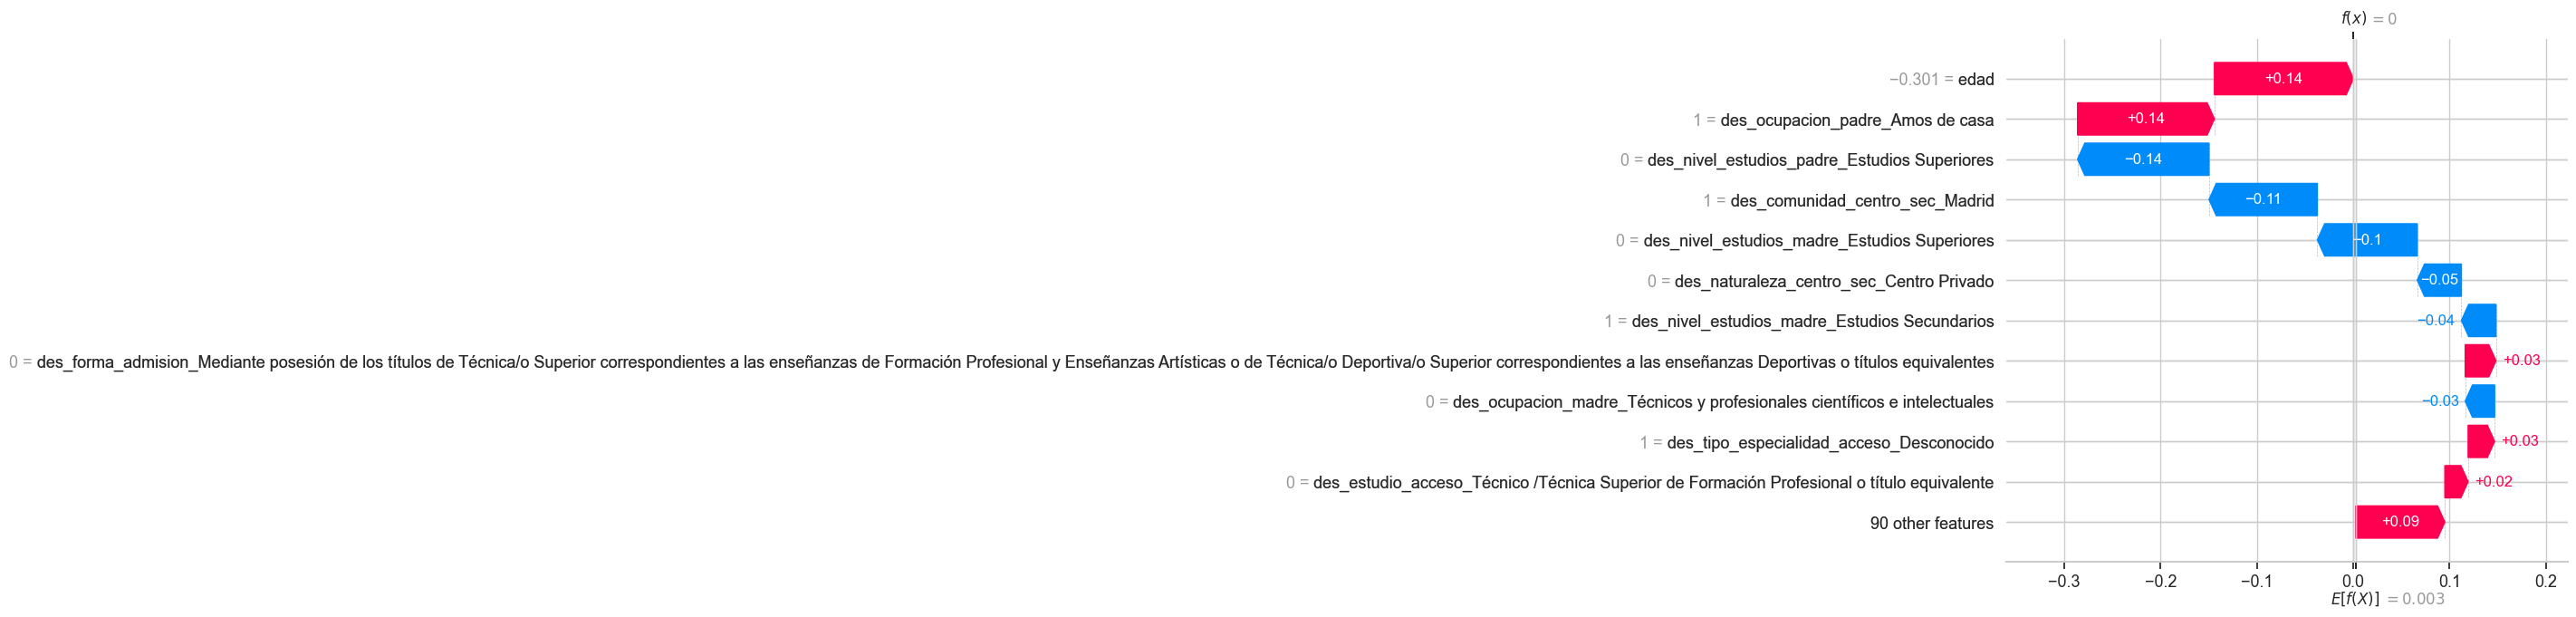

<Figure size 640x480 with 0 Axes>

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_casos[2],
        base_values=float(np.asarray(expected_value).squeeze()),
        data=X_test_t[idx_border],
        feature_names=feature_names_clean,
    ),
    max_display=12,
    show=True,
)
plt.savefig("figuras/14_story3_shap_waterfall.png", dpi=120, bbox_inches="tight")

#### **Narrativa caso 3:**

El gráfico limite (Story 3) muestra
f(x) = 0, lo que equivale a una probabilidad exacta del 50%.
A diferencia de los casos anteriores, no existe ninguna variable dominante que incline la balanza —
todas las contribuciones son pequeñas y de signos opuestos. Por el lado positivo, la juventud del
estudiante (edad estandarizada −0.301, +0.14) y la ocupación del padre como amo de casa (+0.14) empujan
levemente hacia nota alta, junto con la suma agregada de muchas features menores (+0.09). Por el lado
negativo, la ausencia de estudios superiores tanto del padre (−0.14) como de la madre (−0.10), proceder
de Madrid (−0.11) y no venir de un centro privado (−0.05) contrarrestan exactamente esos empujes. El
resultado es un perfil en equilibrio inestable: un estudiante joven pero sin el capital educativo familiar
que el modelo asocia con nota alta, y sin ninguna señal territorial o institucional clara que lo
desempate. 

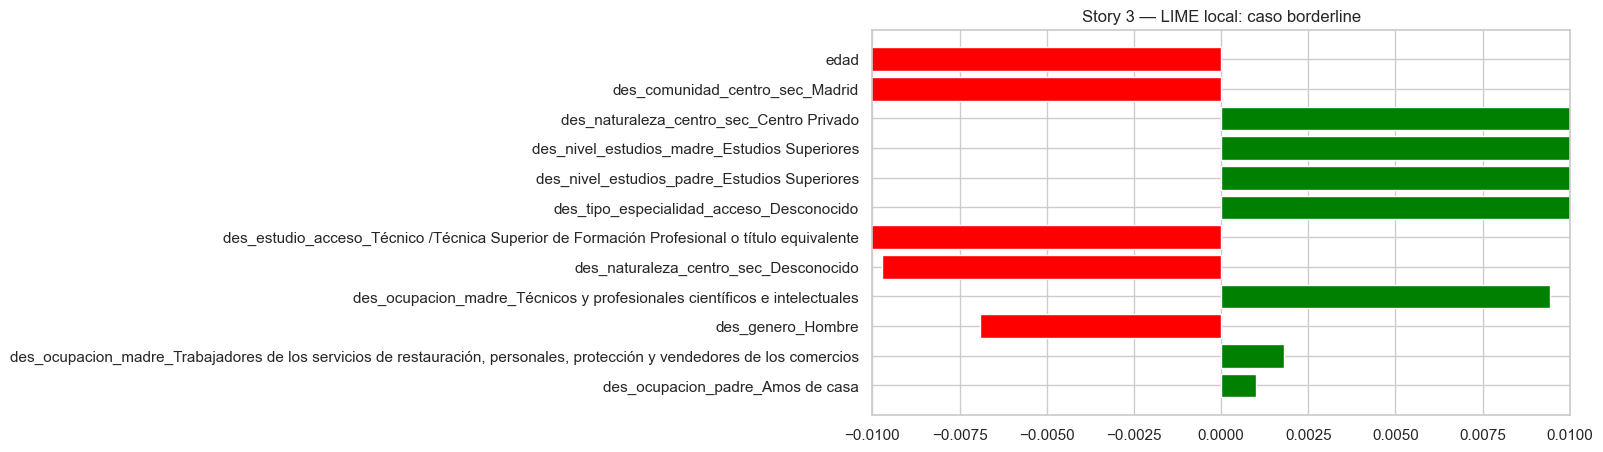

In [169]:
exp3 = lime_explainer.explain_instance(
    data_row=np.array(X_test_t[idx_border]),
    predict_fn=predict_fn,
    num_features=12,
)
fig = exp3.as_pyplot_figure() 
ax = fig.axes[0] # Ajuste manual del eje x para mejorar visualización
ax.set_xlim(-0.01, 0.01)
fig.set_size_inches(9, 5)
plt.title("Story 3 — LIME local: caso borderline")
plt.tight_layout()
plt.savefig("figuras/15_story3_lime.png", dpi=120, bbox_inches="tight")
plt.show()

#### **Comparación SHAP vs LIME (Story 3):** 

En este caso de máxima incertidumbre,
LIME también refleja la ambigüedad del modelo: las contribuciones positivas y
negativas tienen magnitudes similares y no hay consenso claro entre features.
La coherencia entre SHAP y LIME refuerza la conclusión de que el modelo no
dispone de información suficiente para inclinar la balanza, más allá de que
las dos técnicas coincidan en identificar las mismas variables como las de
mayor tensión en ambas direcciones. Este tipo de casos son especialmente conflictivos en sistemas automatizados, requiriendo necesariamente de supervisión humana. 

## 8. Counterfactuals


En esta sección se utiliza DiCE (Diverse Counterfactual Explanations) para analizar cómo pequeños cambios en el perfil de un estudiante pueden modificar la predicción del modelo. A diferencia de las explicaciones locales obtenidas con SHAP o LIME, los counterfactuals permiten explorar escenarios alternativos y entender qué variables son más determinantes para alterar la decisión final del clasificador.

Analizamos dos casos distintos: un estudiante clasificado incorrectamente como “nota alta” (Story 2) y otro correctamente clasificado como “nota baja”. En el primer caso se estudia qué modificaciones harían que el modelo cambiase su predicción hacia “nota baja”, mientras que en el segundo se analiza qué cambios serían necesarios para obtener una predicción de “nota alta”. La comparación entre ambos escenarios permite identificar posibles asimetrías en el comportamiento del modelo y discutir sus implicaciones desde una perspectiva de interpretabilidad y equidad.

In [179]:

import dice_ml
from dice_ml import Dice

# Datos en formato DiCE (incluye el target)
df_dice = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True).rename("nota_alta")],
    axis=1,
)
d_dice = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=["edad"],
    outcome_name="nota_alta",
)
m_dice = dice_ml.Model(model=mejor_pipe, backend="sklearn")
exp_dice = Dice(d_dice, m_dice, method="random")

# --- Caso A: clasificado incorrectamente como "nota alta" (Story 2) ---
print("=== Counterfactuals — Caso A: error del modelo (predice nota alta, real: baja) ===")
print(f"P(nota alta) original: {proba_test[idx_wrong]:.3f}\n")
cf_a = exp_dice.generate_counterfactuals(
    X_test.iloc[[idx_wrong]],
    total_CFs=3,
    desired_class=1,
    random_seed=RANDOM_STATE,
)
cf_a.visualize_as_dataframe(show_only_changes=True)

# --- Caso B: estudiante de nota baja correctamente clasificado ---
mask_correct_low = (
    (y_test.values == 0) &
    (np.array(y_pred_best) == 0) &
    (proba_test < 0.25)
)
idx_low = int(np.where(mask_correct_low)[0][0])
print(f"\n=== Counterfactuals — Caso B: nota baja correctamente clasificada ===")
print(f"P(nota alta) original: {proba_test[idx_low]:.3f}\n")
cf_b = exp_dice.generate_counterfactuals(
    X_test.iloc[[idx_low]],
    total_CFs=3,
    desired_class=1,
    random_seed=RANDOM_STATE,
)
cf_b.visualize_as_dataframe(show_only_changes=True)

=== Counterfactuals — Caso A: error del modelo (predice nota alta, real: baja) ===
P(nota alta) original: 0.217



100%|██████████| 1/1 [00:00<00:00, 10.87it/s]

Query instance (original outcome : 0)


,des_comunidad_centro_sec,des_naturaleza_centro_sec,des_estudio_acceso,des_tipo_especialidad_acceso,des_forma_admision,des_genero,des_familia_numerosa,des_nivel_estudios_madre,des_nivel_estudios_padre,des_ocupacion_madre,des_ocupacion_padre,des_agregacion_paises_nacionalidad,des_dedicacion,edad,nota_alta
0,Desconocido,Desconocido,Técnico /Técnica Superior de Formación Profesi...,Formación profesional o título equivalente,"Pruebas de Acceso a la Universidad (EVAU, PAU ...",Hombre,No,Estudios Superiores,Estudios Secundarios,Directores y gerentes,Jubilado,Europa meridional,Tiempo completo,21,0



Diverse Counterfactual set (new outcome: 1)


...

100%|██████████| 1/1 [00:00<00:00, 13.87it/s]

Query instance (original outcome : 0)


,des_comunidad_centro_sec,des_naturaleza_centro_sec,des_estudio_acceso,des_tipo_especialidad_acceso,des_forma_admision,des_genero,des_familia_numerosa,des_nivel_estudios_madre,des_nivel_estudios_padre,des_ocupacion_madre,des_ocupacion_padre,des_agregacion_paises_nacionalidad,des_dedicacion,edad,nota_alta
0,Madrid,Desconocido,Bachillerato LOMCE,Bachillerato LOMCE,"Pruebas de Acceso a la Universidad (EVAU, PAU ...",Hombre,No,Estudios Superiores,Sin Estudios,Empleados de tipo contable y administrativo,"Otra situación (Rentistas,…)",Europa meridional,Tiempo completo,19,0



Diverse Counterfactual set (new outcome: 1)


,des_comunidad_centro_sec,des_naturaleza_centro_sec,des_estudio_acceso,des_tipo_especialidad_acceso,des_forma_admision,des_genero,des_familia_numerosa,des_nivel_estudios_madre,des_nivel_estudios_padre,des_ocupacion_madre,des_ocupacion_padre,des_agregacion_paises_nacionalidad,des_dedicacion,edad,nota_alta
0,Aragón,-,-,-,-,-,-,-,-,-,-,-,-,16,1
1,Extremadura,Centro Público,-,-,-,-,-,-,-,-,-,-,-,-,1
2,-,-,-,Desconocido,-,-,-,-,-,-,-,-,-,17,1


En el primer caso tomamos una instancia incorrectamente clasisificada. Su perfil se corresponde, en general, con el de un estudiante procedente de estudios de de FP (21 años). Su contexto familiar parece razonablemente acomodado (madre con estudios superiores y ocupación directores y gerentes y padre jubilado). La edad parece indicar además que ha realizado estudios de FP tras la secundaria y accede directamente al grado. 

Los contrafactuales generados incluyen: 
- Cambiar la comunidad de origen (Madrid sale siempre perjudicada) y la profesión del padre, de jubilado a técnico. 
- Cambiar la edad del estudiante y la ocupación del padre (de jubilado a incapacitado).
- Cambiar la edad del estudiante y la especialidad de acceso. 

El modelo parece estar penalizando factores ya conocidos: edad, contexto socioeconomico y FP.

Nota: no existen limitaciones en cuanto a los Counterfactuals generados, lo que implica que pueden no ser accionables, o plausibles. 

En el segundo caso se presenta un estudiante de nota baja correctamente clasificado. Se trata de un estudiante de Madrid cuya madre tiene estudios superiores y se dedica a labores administrativas, y de un padre sin estudios con "otra ocupación". Su origen es de Europa meridonal y entra desde el Bachillerato con 19 años, lo que podría indicar que ha repetido curso. 

El modelo presenta tres conterfactuals: 
- Modificar la edad y la comunidad de acceso: Como se ha mencionado, el modelo penaliza proceder de Madrid, y la edad podría explicitar repetir curso. 
- Modificar la Comunidad y el tipo de centro: El modelo penaliza Madrid y puede beneficiar centros publicos que tengan notas más altas, al acudir presumiblemente los estudiantes de los mismos a universidades publicas con exigentes notas de acceso. 
- Modificar la edad y la especialidad de acceso: De nuevo la edad parece penalizar a este estudiante. Sin embargo, resulta llamativa la especialidad de acceso "Bachillerato LOMCE", ya que a priori debería ser la mejor valorada. 


## 9. Partial Dependence Plots (PDP)


Los **Partial Dependence Plots** permiten visualizar el efecto marginal de una feature sobre la predicción del modelo, promediando sobre la distribución del resto de features (manteniendo el resto fijo a sus valores observados). Mientras que SHAPE o LIME responden *por qué se clasifica así este ejemplo concreto*, los PDP responden *cuál es la relación media entre una feature y la predicción en toda la población*. Esto los convierte en una herramienta especialmente útil para detectar patrones globales y comunicar el comportamiento del modelo a audiencias no técnicas.

Para la feature numérica `edad` usamos `PartialDependenceDisplay` de scikit-learn directamente sobre el pipeline. Para las features categóricas (strings) implementamos PDPs manuales iterando sobre cada categoría y promediando las predicciones del pipeline sobre una muestra del conjunto de entrenamiento.


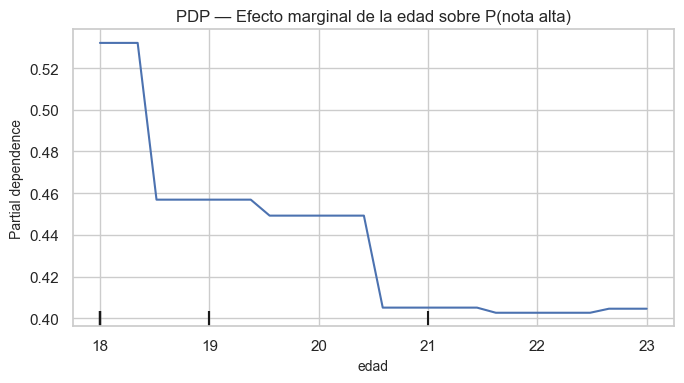

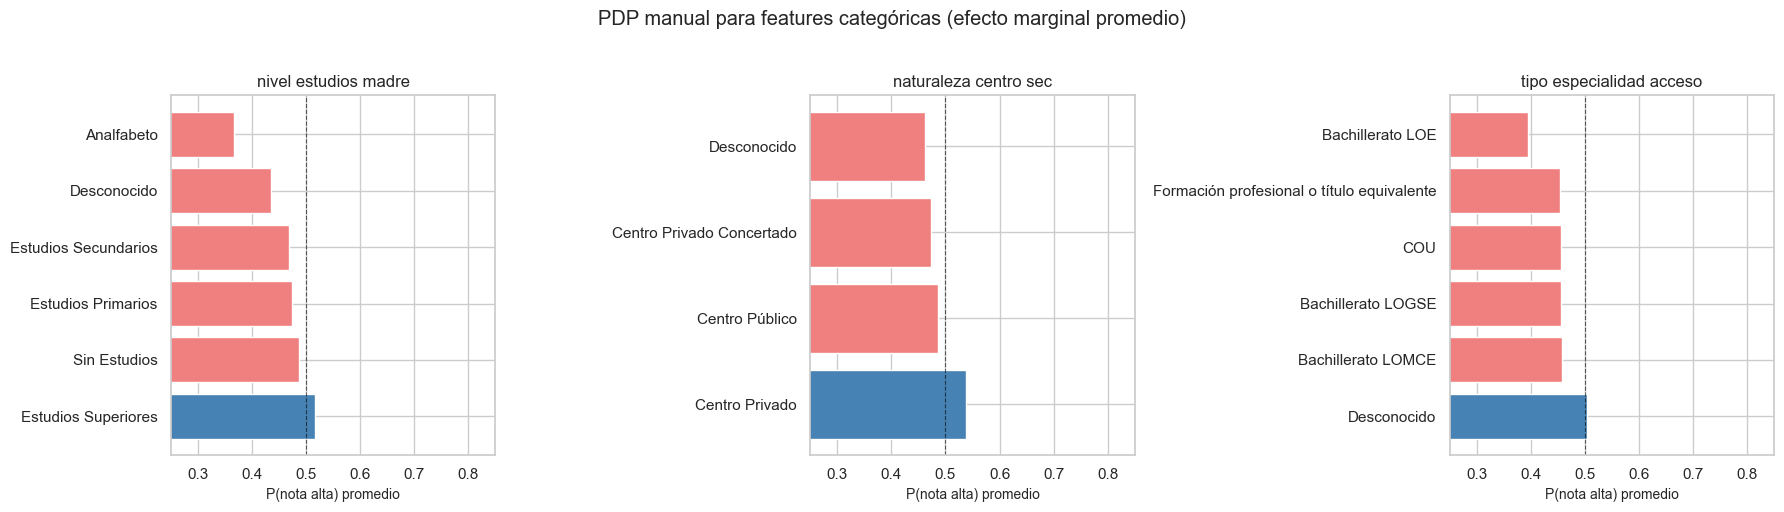

In [171]:
from sklearn.inspection import PartialDependenceDisplay

# --- PDP para 'edad' (feature numérica, sklearn nativo) ---
fig, ax = plt.subplots(figsize=(7, 4))
PartialDependenceDisplay.from_estimator(
    mejor_pipe, X_train, ["edad"],
    kind="average",
    ax=ax,
    grid_resolution=30,
)
ax.set_title("PDP — Efecto marginal de la edad sobre P(nota alta)")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("P(nota alta) parcial")
plt.tight_layout()
plt.savefig("figuras/16_pdp_edad.png", dpi=120, bbox_inches="tight")
plt.show()

# --- PDP manual para features categóricas ---
def pdp_categorica(feature_col, n_sample=1000):
    """PDP: sustituye toda la columna por cada categoría y promedia la predicción."""
    X_pdp = X_train.sample(min(n_sample, len(X_train)), random_state=RANDOM_STATE).copy()
    filas = []
    for cat in X_train[feature_col].unique():
        X_mod = X_pdp.copy()
        X_mod[feature_col] = cat
        prob = mejor_pipe.predict_proba(X_mod)[:, 1].mean()
        filas.append({"categoria": cat, "P(nota_alta)": prob})
    return pd.DataFrame(filas).sort_values("P(nota_alta)", ascending=False).reset_index(drop=True)

pdp_features = [
    "des_nivel_estudios_madre",
    "des_naturaleza_centro_sec",
    "des_tipo_especialidad_acceso",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, pdp_features):
    df_pdp = pdp_categorica(feat)
    colors = ["steelblue" if p >= 0.5 else "lightcoral" for p in df_pdp["P(nota_alta)"]]
    ax.barh(df_pdp["categoria"], df_pdp["P(nota_alta)"], color=colors)
    ax.axvline(0.5, color="black", ls="--", lw=0.8, alpha=0.6)
    ax.set_xlabel("P(nota alta) promedio")
    ax.set_title(feat.replace("des_", "").replace("_", " "))
    ax.set_xlim(0.25, 0.85)

plt.suptitle("PDP manual para features categóricas (efecto marginal promedio)", y=1.02)
plt.tight_layout()
plt.savefig("figuras/17_pdp_categoricas.png", dpi=120, bbox_inches="tight")
plt.show()

### Interpretación de los resultados de los PDP

**PDP de `edad` (variable numérica).**
El gráfico muestra una relación no lineal entre edad y probabilidad de nota alta. Los estudiantes más jóvenes (18–20 años, que acceden directamente tras el bachillerato) presentan la mayor probabilidad de nota alta. A medida que aumenta la edad, la probabilidad desciende de forma pronunciada, lo que refleja que los estudiantes de mayor edad suelen acceder a titulaciones de menor corte o mediante vías alternativas (FP, mayores de 25 años, etc.). Este efecto es el más fuerte de todo el modelo, coherente con que `edad` sea la feature más importante en el análisis SHAP global.

**PDP de `des_nivel_estudios_madre` (variable categórica).**
Las categorías con mayor probabilidad predicha de nota alta corresponden a madres con estudios superiores (universitarios o de posgrado), mientras que las categorías de educación primaria o sin estudios están asociadas a probabilidades notablemente más bajas. Esta dependencia captura un gradiente socioeconómico claro: el capital educativo familiar correlaciona positivamente con el acceso a grados de alta demanda. Desde la perspectiva de la asignatura, este PDP ilustra un **sesgo estructural** del dataset que el modelo aprende y amplifica.

**PDP de `des_naturaleza_centro_sec` (tipo de centro de secundaria).**
Los centros privados y concertados están asociados a probabilidades de nota alta más elevadas que los centros públicos. Esta disparidad no implica necesariamente que el modelo discrimine por tipo de centro de forma injusta: puede reflejar una correlación real con la titulación elegida. Sin embargo, la magnitud de la diferencia —visible en el gráfico de barras— sugiere que el tipo de centro actúa como proxy socioeconómico con un efecto marginal apreciable sobre la predicción.

**PDP de `des_tipo_especialidad_acceso` (modalidad de bachillerato/acceso).**
Las modalidades científico-tecnológicas (Ciencias, Tecnología) presentan las probabilidades más altas, coherente con que los grados STEM tienen cortes de admisión elevados. Las vías de acceso a través de ciclos formativos de grado superior muestran probabilidades intermedias o bajas, dependiendo de la rama. Esto confirma que la vía de acceso es un predictor relevante y que el modelo refleja fielmente la distribución de notas de corte por modalidad en la UCM.



## 10. Anchors

Se utiliza Anchors como otra técnica de explicabilidad local. A diferencia de LIME o SHAP, que producen puntuaciones continuas de importancia de feature, los Anchors generan reglas lógicas suficientes: dado un ejemplo $x$, se busca la regla mínima $A$  tal que la predicción del modelo sea estable con alta probabilidad dentro del vecindario de $x$ que satisface $A$:

 $\tau$ es el umbral de precisión. La regla puede expresarse como una conjunción de condiciones sobre features individuales: `"IF tipo_acceso = EVAU AND titulación = Física THEN nota_alta"`. En el contexto de la asignatura, los Anchors resultan especialmente relevantes porque producen explicaciones contrastivas y accionables en lenguaje natural, lo que los hace adecuados para comunicar decisiones a usuarios no técnicos. El trade-off clave se da entre precisión (¿con qué fiabilidad la regla predice la clase?) y cobertura (¿a qué fracción de instancias se aplica la regla?): reglas más simples tienen mayor cobertura pero menor precisión, y viceversa.

Para trabajar con features de tipo cadena de texto, se codifican previamente las variables categóricas con `OrdinalEncoder` y se encapsula la decodificación en la función de predicción.

In [172]:
from sklearn.preprocessing import OrdinalEncoder
from anchor import anchor_tabular

# Codificación ordinal: Anchor necesita arrays numéricos
ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_ord = X_train.copy()
X_test_ord = X_test.copy()
X_train_ord[features_cat] = ord_enc.fit_transform(X_train[features_cat])
X_test_ord[features_cat] = ord_enc.transform(X_test[features_cat])

# Nombres de categorías por feature (para que Anchor genere reglas legibles)
cat_names_anchor = {
    i: [str(c) for c in ord_enc.categories_[i]]
    for i in range(len(features_cat))
}

def predict_anchor(X_arr):
    """Decodifica la codificación ordinal y predice con el pipeline original."""
    X_df = pd.DataFrame(X_arr, columns=features_cat + features_num)
    for i, col in enumerate(features_cat):
        cats = ord_enc.categories_[i]
        X_df[col] = X_df[col].apply(
            lambda x: cats[int(round(x))] if 0 <= int(round(x)) < len(cats) else "Desconocido"
        )
    return mejor_pipe.predict(X_df)

explainer_anchor = anchor_tabular.AnchorTabularExplainer(
    class_names=["Nota baja", "Nota alta"],
    feature_names=features_cat + features_num,
    train_data=X_train_ord.values,
    categorical_names=cat_names_anchor,
)

# --- Story 1: caso correctamente clasificado como nota alta ---
print("=== Anchor — Story 1 (nota alta, alta confianza) ===")
exp_a1 = explainer_anchor.explain_instance(
    X_test_ord.iloc[idx_correct].values,
    predict_anchor,
    threshold=0.95,
)
print("Regla:")
for cond in exp_a1.names():
    print(f"  • {cond}")
print(f"\nPrecisión: {exp_a1.precision():.3f}  |  Cobertura: {exp_a1.coverage():.3f}")

# --- Story 3: caso borderline ---
print("\n=== Anchor — Story 3 (borderline, P ≈ 0.5) ===")
exp_a3 = explainer_anchor.explain_instance(
    X_test_ord.iloc[idx_border].values,
    predict_anchor,
    threshold=0.90,  # umbral más bajo porque el caso es ambiguo
)
print("Regla:")
for cond in exp_a3.names():
    print(f"  • {cond}")
print(f"\nPrecisión: {exp_a3.precision():.3f}  |  Cobertura: {exp_a3.coverage():.3f}")

=== Anchor — Story 1 (nota alta, alta confianza) ===
Regla:
  • des_comunidad_centro_sec = Canarias
  • edad <= 18.00

Precisión: 0.971  |  Cobertura: 0.016

=== Anchor — Story 3 (borderline, P ≈ 0.5) ===
Regla:
  • edad <= 18.00
  • des_ocupacion_padre = Amos de casa
  • des_forma_admision = Pruebas de Acceso a la Universidad (EVAU, PAU y Pruebas de Acceso anteriores)
  • des_tipo_especialidad_acceso = Desconocido
  • des_genero = Mujer
  • des_dedicacion = Tiempo completo

Precisión: 0.901  |  Cobertura: 0.001


### Interpretación de los resultados de los Anchors

**Story 1 — Caso de alta confianza (nota alta correctamente clasificada).**
La regla `edad ≤ 18 AND comunidad = Canarias` predice "nota alta" con un 97.1% de precisión, pero solo aplica al 1.6% del test. Es una regla muy fiable pero de alcance limitado: el modelo determina que la combinación de juventud y Canarias es equivalente a una buena nota. Esto puede deberse a varios motivos ya mencionados anteriormente. En primer lugar, puede guardar relación con la discusión existente sobre las diferencias de la prueba entre comunidades autónomas. En segundo lugar, captura un patrón socioeconómico indirecto bastante claro: aquellos estudiantes con recursos para cambiar de comunidad autónoma suelen partir de un contexto socioeconómico favorable y, por tanto, obtienen buenas notas. Esta conclusión refuerza el hallazgo SHAP de que la edad y la comunidad de procedencia tienen mucho peso en el modelo.

**Story 3 — Caso borderline (P ≈ 0.5).**
Aquí hacen falta seis condiciones para alcanzar una precisión del 90.1%, y la regla cubre solo el 0.1% del test, un porcentaje de prácticamente un caso. Esto confirma lo que ya mostraba el SHAP del caso límite, el modelo no sabe que deicidir sobre este estudiante. La regla es casi una descripción del propio individuo, no pudiendose extraer conclusiones de ella. Además, la condición `des_tipo_especialidad_acceso = Desconocido` es reveladora: el modelo se apoya en información faltante, no en una combinación informativa de features. En conjunto, contraste perfecto con Story 1: cuando el modelo está seguro, le bastan dos condiciones para abarcar muchos casos similares, cuando duda, necesita seis y aun así solo se aplica a un caso.


## 11. Auditoría de Equidad con Aequitas

En esta sección se realiza un analisis de equidad usando Aequitas, que estructura el análisis en tres capas:

| Capa | Clase | Qué proporciona |
|---|---|---|
| **Análisis de grupo** | `Group` | Métricas brutas por subgrupo: TPR, FPR, PPR, FNR, prevalencia… |
| **Análisis de sesgo** | `Bias` | Ratios de disparidad respecto a un grupo de referencia |
| **Evaluación de equidad** | `Fairness` | Veredicto binario pass/fail por grupo y criterio, con umbral configurable |

Se considerará que el sistema es equitativo si el ratio de disparidad de cualquier grupo respecto al grupo de referencia cae en el intervalo **[0.80, 1.25]**. Este es el umbral estándar de facto en auditorías de equidad algorítmica y el valor por defecto en Aequitas.

Las tres variables sensibles que usaremos en el análisis Aequitas serán:

- `genero` — mapeada desde `des_genero` del dataset original
- `centro_sec` — mapeada desde `des_naturaleza_centro_sec` (tipo de centro de secundaria: público, privado, concertado)
- `nivel_madre` — mapeada desde `des_nivel_estudios_madre` (nivel educativo de la madre, proxy socioeconómico)


In [173]:

from aequitas.group import Group
from aequitas.bias import Bias
from aequitas.fairness import Fairness


In [174]:
# Aequitas requiere: 'score' (predicción 0/1), 'label_value' (etiqueta real 0/1)
# y columnas de atributos protegidos como strings.

# Mapeado de etiquetas largas de nivel educativo a versiones compactas
_nivel_map = {
    "Educación Primaria o inferior": "Primaria",
    "Educación Secundaria Obligatoria": "Secundaria",
    "Bachillerato o equivalente": "Bachillerato",
    "FP de Grado Medio": "FP Medio",
    "FP de Grado Superior": "FP Superior",
    "Estudios Universitarios de 1er o 2do ciclo": "Universidad",
    "Estudios Universitarios de 3er ciclo": "Doctorado",
    "Sin estudios": "Sin estudios",
    "Desconocido": "Desconocido",
}

df_aeq = pd.DataFrame({
    "score":       np.array(y_pred_best).astype(int),
    "label_value": y_test.values.astype(int),
    "genero":      X_test["des_genero"].values.astype(str),
    "centro_sec":  X_test["des_naturaleza_centro_sec"].values.astype(str),
    "nivel_madre": [_nivel_map.get(str(x), str(x))
                    for x in X_test["des_nivel_estudios_madre"].values],
})

# Grupos de referencia: grupo más frecuente de cada variable sensible
attr_cols = ["genero", "centro_sec", "nivel_madre"]
ref_groups = {col: df_aeq[col].value_counts().idxmax() for col in attr_cols}

print("Distribución de grupos en el conjunto de test:")
for col in attr_cols:
    print(f"\n  {col}  (grupo de referencia: '{ref_groups[col]}'):")
    counts = df_aeq[col].value_counts()
    for val, n in counts.items():
        print(f"    {val:<40}  n={n}")

Distribución de grupos en el conjunto de test:

  genero  (grupo de referencia: 'Mujer'):
    Mujer                                     n=1757
    Hombre                                    n=916

  centro_sec  (grupo de referencia: 'Centro Público'):
    Centro Público                            n=1274
    Centro Privado                            n=824
    Desconocido                               n=475
    Centro Privado Concertado                 n=100

  nivel_madre  (grupo de referencia: 'Estudios Superiores'):
    Estudios Superiores                       n=1690
    Estudios Secundarios                      n=717
    Estudios Primarios                        n=159
    Desconocido                               n=75
    Sin Estudios                              n=24
    Analfabeto                                n=8


In [175]:
# ── Capa 1: Análisis de Grupo — métricas brutas por subgrupo ──────────────
g = Group() # Grupo de analisis 
xtab, _ = g.get_crosstabs(df_aeq, attr_cols=attr_cols)

cols_interes = [
    "attribute_name", "attribute_value", "group_size", 
    "prev",       # prevalencia real de nota_alta en el grupo
    "ppr",        # positive prediction rate = P(ŷ=1 | grupo)
    "tpr",        # true positive rate — Equal Opportunity
    "fpr",        # false positive rate
    "fnr",        # false negative rate = 1 - TPR
    "tnr",        # true negative rate
    "precision",  # PPV = precisión
]
cols_disp = [c for c in cols_interes if c in xtab.columns]

print("Métricas brutas por subgrupo (Aequitas — Group layer)")
print("─" * 95)
with pd.option_context("display.float_format", "{:.3f}".format,
                        "display.max_rows", 60,
                        "display.max_colwidth", 35):
    print(
        xtab[cols_disp]
        .sort_values(["attribute_name", "ppr"], ascending=[True, False])
        .to_string(index=False)
    )

Métricas brutas por subgrupo (Aequitas — Group layer)
───────────────────────────────────────────────────────────────────────────────────────────────
attribute_name           attribute_value  group_size  prev   ppr   tpr   fpr   fnr   tnr  precision
    centro_sec            Centro Público        1274 0.498 0.457 0.635 0.412 0.365 0.588      0.605
    centro_sec            Centro Privado         824 0.524 0.375 0.764 0.554 0.236 0.446      0.603
    centro_sec               Desconocido         475 0.476 0.138 0.487 0.365 0.513 0.635      0.547
    centro_sec Centro Privado Concertado         100 0.440 0.030 0.545 0.339 0.455 0.661      0.558
        genero                     Mujer        1757 0.515 0.690 0.668 0.470 0.332 0.530      0.601
        genero                    Hombre         916 0.473 0.310 0.607 0.391 0.393 0.609      0.582
   nivel_madre       Estudios Superiores        1690 0.536 0.758 0.732 0.564 0.268 0.436      0.600
   nivel_madre      Estudios Secundarios         7

El código crea un objeto Group() y luego calcula, mediante get_crosstabs, una tabla con métricas estadísticas por grupo usando el DataFrame df_aeq y las columnas sensibles definidas en attr_cols. Después selecciona métricas relevantes como el tamaño del grupo (group_size), la prevalencia real (prev), la tasa de predicciones positivas (ppr), la tasa de verdaderos positivos (tpr), falsos positivos (fpr), falsos negativos (fnr), verdaderos negativos (tnr) y la precisión (precision). El

In [176]:
# ── Capa 2: Análisis de Sesgo — ratios de disparidad vs grupo de referencia ─
b = Bias() 
bdf = b.get_disparity_predefined_groups(
    xtab,
    original_df=df_aeq,
    ref_groups_dict=ref_groups,
    alpha=0.05,
)

disp_candidates = [
    "ppr_disparity", "tpr_disparity", "fpr_disparity",
    "fnr_disparity", "precision_disparity",
]
disp_cols = [c for c in disp_candidates if c in bdf.columns]

print("Ratios de disparidad (Aequitas — Bias layer)")
print("ratio = métrica_grupo / métrica_grupo_referencia  |  equitativo si ∈ [0.80, 1.25]")
print("─" * 75)
with pd.option_context("display.float_format", "{:.3f}".format, "display.max_rows", 60):
    print(bdf[["attribute_name", "attribute_value", "group_size"] + disp_cols]
          .sort_values(["attribute_name", disp_cols[0]], ascending=[True, True])
          .to_string(index=False))



Ratios de disparidad (Aequitas — Bias layer)
ratio = métrica_grupo / métrica_grupo_referencia  |  equitativo si ∈ [0.80, 1.25]
───────────────────────────────────────────────────────────────────────────
attribute_name           attribute_value  group_size  ppr_disparity  tpr_disparity  fpr_disparity  fnr_disparity  precision_disparity
    centro_sec Centro Privado Concertado         100          0.065          0.859          0.824          1.244                0.922
    centro_sec               Desconocido         475          0.302          0.767          0.888          1.405                0.904
    centro_sec            Centro Privado         824          0.821          1.204          1.345          0.646                0.997
    centro_sec            Centro Público        1274          1.000          1.000          1.000          1.000                1.000
        genero                    Hombre         916          0.450          0.909          0.832          1.183               

Se compara cada subgrupo con un grupo de referencia definido en ref_groups. Primero se crea un objeto Bias() y luego se calculan las disparidades mediante get_disparity_predefined_groups, usando como entrada las métricas previamente obtenidas en xtab, el DataFrame original df_aeq y los grupos de referencia. El resultado (bdf) contiene ratios de disparidad para distintas métricas, como ppr_disparity, tpr_disparity, fpr_disparity, fnr_disparity y precision_disparity, donde cada ratio se calcula como la métrica del grupo dividida entre la métrica del grupo de referencia. 

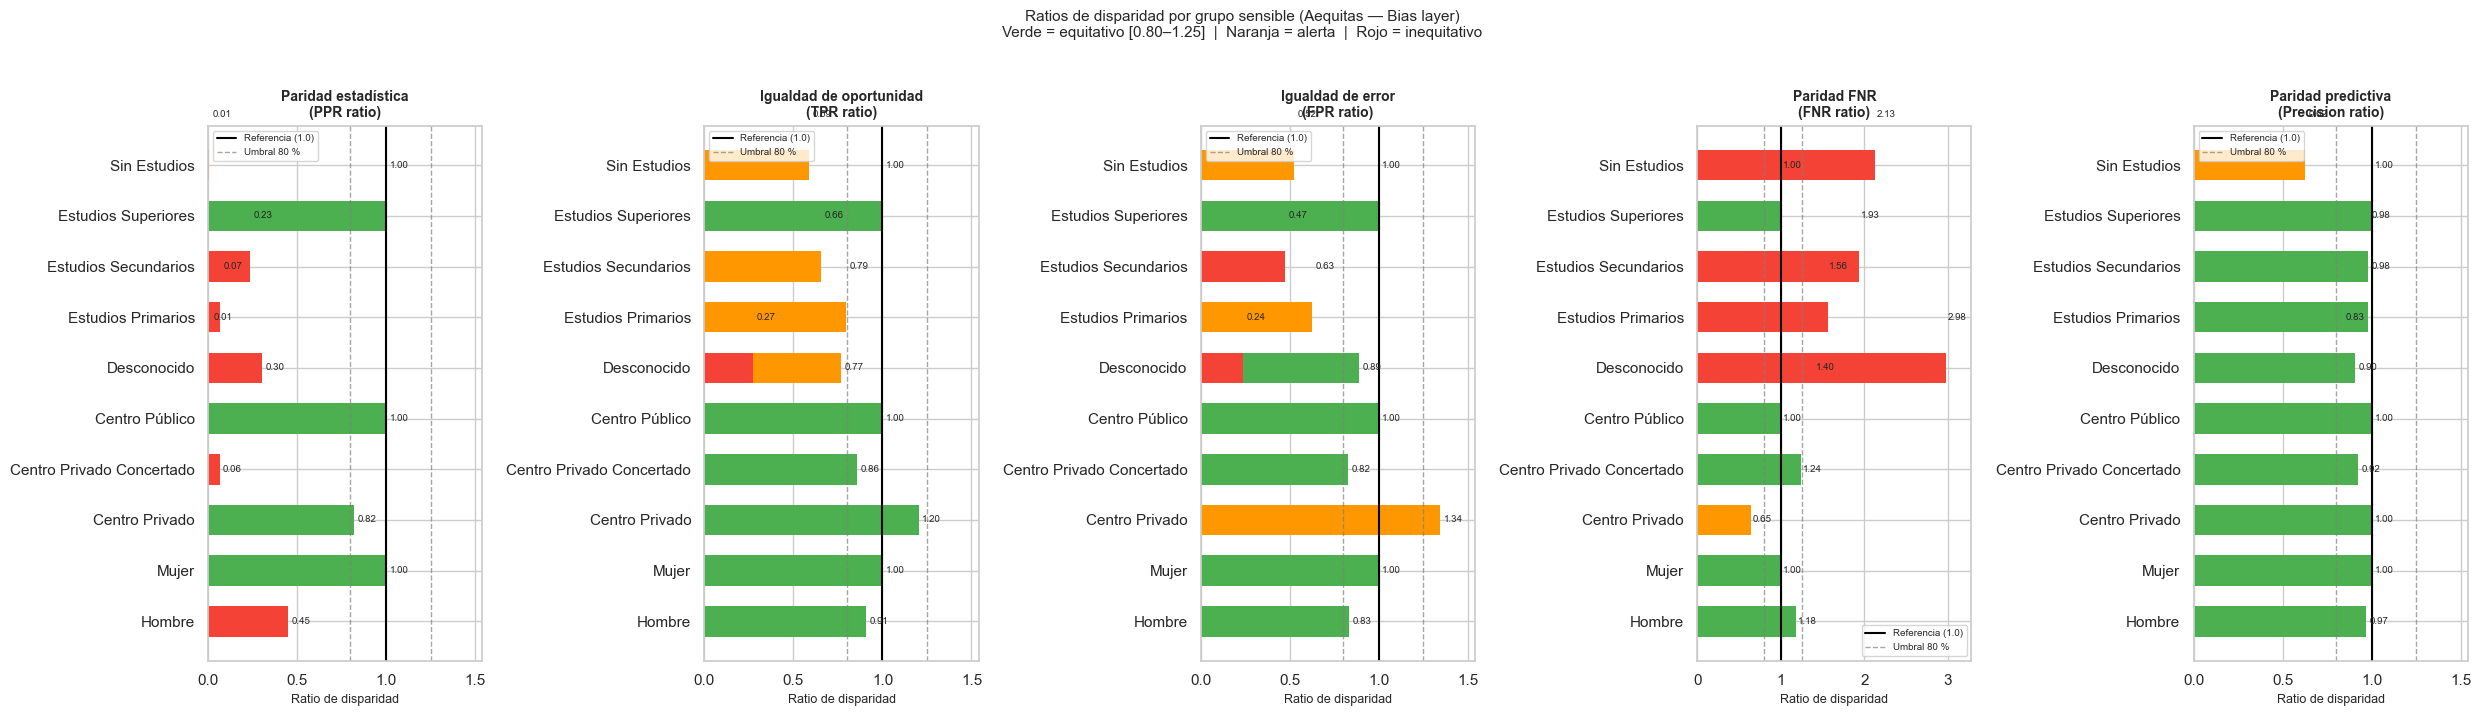

In [177]:
# ── Visualización ─────────────────────────────────────────────────────────
disp_labels = {
    "ppr_disparity":       "Paridad estadística\n(PPR ratio)",
    "tpr_disparity":       "Igualdad de oportunidad\n(TPR ratio)",
    "fpr_disparity":       "Igualdad de error\n(FPR ratio)",
    "fnr_disparity":       "Paridad FNR\n(FNR ratio)",
    "precision_disparity": "Paridad predictiva\n(Precision ratio)",
}
metr_plot = [m for m in disp_labels if m in bdf.columns]

fig, axes = plt.subplots(1, len(metr_plot), figsize=(5 * len(metr_plot), 7))
if len(metr_plot) == 1:
    axes = [axes]

for ax, metric in zip(axes, metr_plot):
    sub = bdf[["attribute_value", "group_size", metric]].dropna()
    sub = sub[sub["group_size"] >= 20].copy()
    vals = sub[metric].values

    colors = ["#4CAF50" if 0.8 <= v <= 1.25 else
              ("#FF9800" if 0.5 <= v <= 1.5  else "#F44336")
              for v in vals]

    ax.barh(sub["attribute_value"].values, vals, color=colors, edgecolor="none", height=0.6)
    ax.axvline(1.00, color="black", lw=1.5, ls="-",  label="Referencia (1.0)")
    ax.axvline(0.80, color="gray",  lw=1.0, ls="--", alpha=0.7, label="Umbral 80 %")
    ax.axvline(1.25, color="gray",  lw=1.0, ls="--", alpha=0.7)
    ax.set_xlabel("Ratio de disparidad", fontsize=9)
    ax.set_title(disp_labels[metric], fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)
    max_val = max(vals.max(), 1.4) if len(vals) > 0 else 1.5
    ax.set_xlim(0, max_val * 1.1)
    for i, v in enumerate(vals):
        ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=7)

plt.suptitle(
    "Ratios de disparidad por grupo sensible (Aequitas — Bias layer)\n"
    "Verde = equitativo [0.80–1.25]  |  Naranja = alerta  |  Rojo = inequitativo",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig("figuras/18_aequitas_disparidades.png", dpi=120, bbox_inches="tight")
plt.show()

Criterios de equidad evaluados (16): ['model_id', 'Statistical Parity', 'Impact Parity', 'FDR Parity', 'FPR Parity', 'FOR Parity', 'FNR Parity', 'TPR Parity', 'TNR Parity', 'NPV Parity', 'Precision Parity', 'TypeI Parity', 'TypeII Parity', 'Equalized Odds', 'Unsupervised Fairness', 'Supervised Fairness']


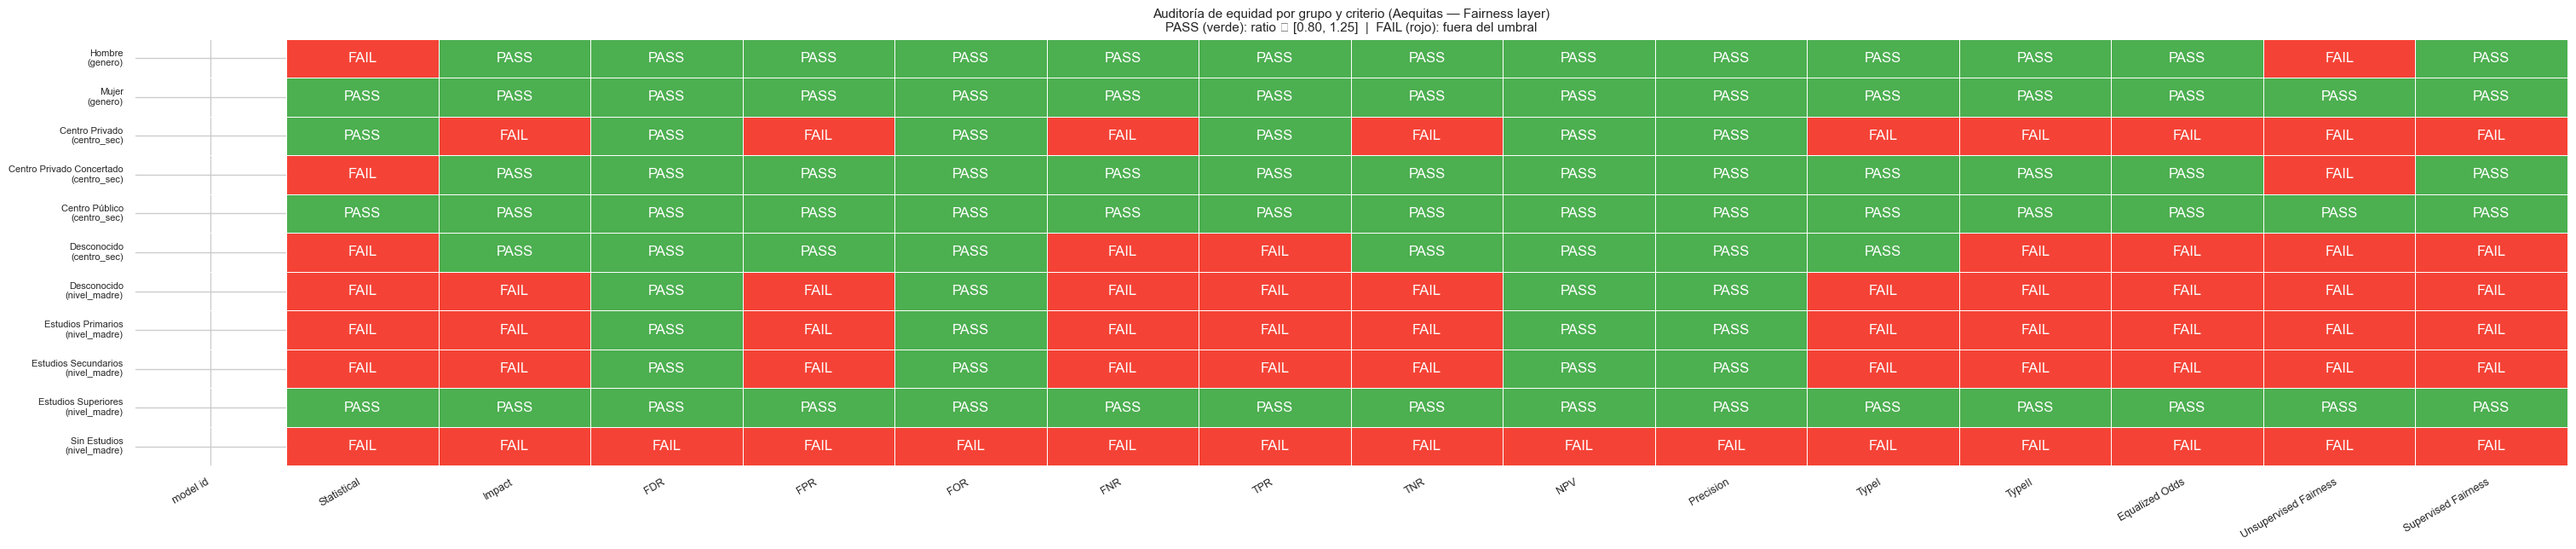

In [178]:
# ── Capa 3: Evaluación de Equidad — veredicto binario pass/fail por criterio ─
f = Fairness()
fdf = f.get_group_value_fairness(bdf)

# Detectar columnas de equidad (booleanos) de forma robusta
bool_cols = [c for c in fdf.columns
             if fdf[c].dtype == bool or
             (c not in ('attribute_name','attribute_value','group_size','score','label_value')
              and set(fdf[c].dropna().unique()).issubset({True, False}))]
# Si no hay booleanos, buscar por palabras clave habituales en Aequitas
if not bool_cols:
    bool_cols = [c for c in fdf.columns
                 if any(kw in c for kw in ("Parity","Fairness","fair","supervised","unsupervised"))]

print(f"Criterios de equidad evaluados ({len(bool_cols)}): {bool_cols}")

if bool_cols:
    plot_df = fdf[fdf["group_size"] >= 20].copy()
    plot_df["grupo_label"] = (
        plot_df["attribute_value"].str[:28] + "\n(" + plot_df["attribute_name"] + ")"
    )
    pivot = plot_df.set_index("grupo_label")[bool_cols]

    # True → 1 (PASS), False → 0 (FAIL), None/NaN → nan
    def _to_01(x):
        if x is True:  return 1
        if x is False: return 0
        return float('nan')

    pivot_num  = pivot.apply(lambda col: col.map(_to_01))
    annot_df   = pivot.apply(lambda col: col.map(
        lambda x: "PASS" if x is True else ("FAIL" if x is False else "—")
    ))
    col_clean  = {c: c.replace(" Parity","").replace("_disparity_fair","")
                       .replace("_"," ") for c in bool_cols}

    fig, ax = plt.subplots(
        figsize=(max(8, len(bool_cols) * 1.9), max(5, len(pivot_num) * 0.6))
    )
    sns.heatmap(
        pivot_num.rename(columns=col_clean),
        ax=ax,
        cmap=["#F44336", "#4CAF50"],
        vmin=0, vmax=1,
        linewidths=0.6, linecolor="white",
        annot=annot_df.rename(columns=col_clean),
        fmt="",
        cbar=False,
    )
    ax.set_title(
        "Auditoría de equidad por grupo y criterio (Aequitas — Fairness layer)\n"
        "PASS (verde): ratio ∈ [0.80, 1.25]  |  FAIL (rojo): fuera del umbral",
        fontsize=11,
    )
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.xticks(rotation=30, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig("figuras/19_aequitas_fairness_heatmap.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No se encontraron columnas de equidad. Columnas disponibles:")
    print(list(fdf.columns))

Este código utiliza la capa Fairness de Aequitas para convertir los ratios de disparidad calculados previamente en un veredicto binario de equidad para cada grupo y criterio. Primero crea un objeto Fairness() y genera fdf mediante get_group_value_fairness(bdf), que evalúa si cada métrica cumple o no los umbrales de equidad establecidos, normalmente considerando como aceptables los ratios dentro del rango [0.80, 1.25]. Después detecta de forma robusta qué columnas representan criterios de equidad, priorizando columnas booleanas con valores True o False, y si no las encuentra busca nombres habituales usados por Aequitas. Si existen criterios de equidad, filtra los grupos con al menos 20 observaciones, crea una etiqueta legible para cada subgrupo y transforma los valores booleanos en números para poder representarlos en un mapa de calor: True se muestra como PASS, False como FAIL y los valores ausentes como “—”. Finalmente, el código genera un heatmap donde el color verde indica que el grupo cumple el criterio de equidad y el rojo indica que no lo cumple,.

### 11.1 Interpretación


El primer gráfico corresponde a la capa Bias de Aequitas y muestra los ratios de disparidad de distintas métricas respecto al grupo de referencia para varios atributos sensibles (nivel educativo de la madre, tipo de centro y género). Los colores indican el nivel de equidad: verde representa valores considerados equitativos dentro del rango [0.80, 1.25], naranja indica alerta y rojo evidencia posibles problemas de sesgo. En la métrica de paridad estadística (PPR ratio) se observan desigualdades importantes: grupos como Hombre, Estudios Secundarios, Estudios Primarios y Centro Privado Concertado presentan ratios muy bajos, lo que implica que reciben muchas menos predicciones positivas que el grupo de referencia. En igualdad de oportunidad (TPR ratio) la mayoría de grupos se mantiene relativamente cerca del umbral aceptable, aunque Sin Estudios y algunos niveles educativos bajos muestran peores resultados, indicando que el modelo detecta peor los casos positivos reales en esos colectivos. Respecto a la igualdad de error (FPR ratio), el grupo Centro Privado supera el límite superior, lo que significa que sufre más falsos positivos que el grupo de referencia, mientras que otros grupos presentan ratios bajos. La métrica más problemática es la paridad FNR, donde varios grupos superan ampliamente el valor 1, especialmente Estudios Primarios y Desconocido, indicando que el modelo falla mucho más al identificar positivos reales en esos colectivos. Finalmente, la paridad predictiva (Precision ratio) es la métrica más equilibrada, ya que casi todos los grupos permanecen dentro del rango aceptable.

El segundo gráfico corresponde a la capa Fairness y resume los resultados anteriores en un mapa binario de cumplimiento (“PASS” o “FAIL”) para cada criterio de equidad. El verde indica que el grupo cumple el criterio y el rojo que lo incumple. El patrón general muestra que los grupos relacionados con niveles educativos bajos o desconocidos concentran la mayor cantidad de fallos, especialmente en criterios asociados a tasas de error (FPR, FNR, TNR) y fairness supervisada/no supervisada. El grupo Sin Estudios destaca como el más problemático, ya que prácticamente falla en todos los criterios evaluados, lo que sugiere una fuerte desigualdad sistemática del modelo hacia este colectivo. En contraste, grupos como Mujer, Centro Público y Estudios Superiores presentan una auditoría mucho más favorable, con predominio de resultados “PASS”. También se aprecia que el atributo de género genera menos problemas de equidad que el nivel educativo, aunque el grupo Hombre falla en paridad estadística y fairness no supervisada. En conjunto, ambos gráficos indican que el modelo presenta sesgos más marcados asociados al nivel educativo y, en menor medida, al tipo de centro educativo, mientras que las diferencias por género son relativamente moderadas.

## 12 Conclusiones

### 12.1 Resumen del trabajo

Este trabajo analiza el conjunto de datos público de admisiones de la Universidad Complutense de Madrid (curso 2024-2025), compuesto por 14.019 registros agregados y 77 columnas, con el objetivo de identificar qué factores del perfil socioeducativo de un estudiante determinan si obtiene una nota de admisión superior a la mediana. La tarea se plantea como clasificación binaria (`nota_alta = 1 si nota_admision ≥ mediana`), comparando tres clasificadores: Regresión Logística, Random Forest e Histogram Gradient Boosting. Este último es seleccionado como modelo final por su capacidad para capturar efectos no lineales y por permitir la aplicación de `TreeExplainer` (SHAP exacto). Sobre el modelo seleccionado se aplican varias técnicas XAI: análisis global (SHAP bar plot, beeswarm, PDP), explicaciones locales (SHAP waterfall, LIME, Anchors), contrafactuales (DiCE) y auditoría de equidad (Aequitas).

---

### 12.2 Principales hallazgos

**Factores predictivos más relevantes (perspectiva global):**

- **La edad.** Los estudiantes más jóvenes (18-20 años, acceso directo por bachillerato) presentan una probabilidad sensiblemente mayor de nota alta. El efecto es consistente entre SHAP y LIME. La edad actúa como proxy de la vía de acceso: un estudiante de 21 años es, con frecuencia, alguien que ha cursado FP antes de acceder al grado. Estudiantes mayores constituyen un grupo menos numerosos y con notas potenicalmente más bajas. 
- **El lugar de procedencia.** La comunidad autónoma donde se cursó la secundaria tiene un peso notable. El modelo beneficia Canarias, perjudica Madrid. Esto puede tener implicaciones socioeconomicas: estudiantes procedentes de otras comunidades tienen más recursos. Por otro lado, puede influir la dificultad de las pruebas entre comunidades, un debate que se encuentra abierto. 
- **La titularidad del centro de secundaria.** El modelo, en general, beneficia proceder de un centro privado.
- **Contexto socioeconómico** Los estudios superiores y las ocupaciones técnico-científicas de los progenitores —especialmente de la madre— empujan la predicción al alza. 
- **La vía de acceso.** La EVAU/PAU está asociada a notas más altas que las vías alternativas (FP, mayores de 25/40/45 años, traslados). Los contrafactuales (DiCE) confirman que cambiar la vía de acceso de FP a Bachillerato es uno de los movimientos mínimos suficientes para cambiar la predicción del modelo.
- **El género.** Ser mujer contribuye positivamente a la predicción de nota alta, lo que es coherente con la evidencia académica sobre mayor rendimiento femenino en educación secundaria en España.

**Hallazgos de la auditoría de equidad (Aequitas):**

- La métrica de **paridad estadística (PPR ratio)** falla para hombres, estudiantes de centros públicos y estudiantes con progenitores de nivel educativo primario o secundario.
- La **igualdad de oportunidad (TPR ratio)** y la **paridad predictiva (Precision ratio)** presentan disparidades moderadas en los mismos grupos.
- El modelo no es neutral: reproduce y potencialmente amplifica patrones ya presentes en los datos de admisión.

---

### 12.3 Limitaciones

1. **Los datos son agregados, no individuales.** Cada registro representa un grupo de estudiantes con el mismo perfil demográfico admitidos a la misma titulación, no a una persona concreta. Esto impide un análisis causal a nivel individual y puede introducir sesgos por composición de grupo.

2. **Sesgo de selección estructural.** El dataset solo contiene estudiantes admitidos. No hay información sobre solicitantes rechazados, lo que hace imposible modelar la selectividad real o estudiar los determinantes del rechazo.

3. **La edad encapsula múltiples mecanismos.** Aunque es el predictor más potente, es difícil distinguir si el efecto de la edad se debe a la vía de acceso, al rendimiento académico previo, a la titulación solicitada o a factores de motivación. 

4. **El umbral binario pierde información.** Convertir la nota continua en una variable binaria con la mediana como umbral descarta la variabilidad dentro de cada clase. Dos estudiantes con notas de 11.0 o 13.9 reciben la misma etiqueta ("nota alta").

5. **Cobertura temporal y geográfica limitada.** El dataset cubre un único curso académico (2024-25) en una única institución (UCM). Los resultados no son directamente generalizables a otras universidades ni a otros años.

6. **El rendimiento del modelo entrenado es bajo.** Si bien predice mejor que el azar y muestra que es capaz de generalizar, obtiene un rendimiento limitado. 

---

### 12.4 Posibles mejoras

**Sobre los datos:**
- Incorporar datos de estudiantes no admitidos (solicitantes rechazados) para modelar la selectividad real de cada titulación.
- Extender el análisis a múltiples cursos académicos y universidades para evaluar la estabilidad temporal de los patrones y detectar tendencias.

**Sobre la modelización:**
- Plantear el problema como **regresión** sobre la nota continua en lugar de clasificación binaria, preservando la granularidad de la variable objetivo. Este enfoque presenta dificultades en cuanto a las técnicas de explicabilidad
- Incluir `des_titulacion` como variable de control. Intentando evitar el leakage, la variable puede aportar información en validación. 

**Sobre la explicabilidad:**
- Ampliar los **contrafactuales de DiCE** incorporando restricciones de accionabilidad más ricas (por ejemplo, que la edad no pueda disminuir o que el nivel educativo de los progenitores sea inmutable).
- Explorar **Anchors a nivel global** para obtener reglas de cobertura amplia interpretables por audiencias no técnicas.


## 13. Referencias

- Universidad Complutense de Madrid. (2025). Admisiones en la Universidad Complutense de Madrid (Curso 2024–2025) [Conjunto de datos].  [UniversiDATA￼](https://www.universidata.es/datasets/ucm-acceso/recursos/75e6f4e8-e796-424f-ae85-ce857a6941c3#{})
- Parlamento Europeo y Consejo de la Unión Europea. (2024). *Reglamento (UE) 2024/1689 del Parlamento Europeo y del Consejo, de 13 de junio de 2024, por el que se establecen normas armonizadas en materia de inteligencia artificial*. Diario Oficial de la Unión Europea, L 2024/1689. https://eur-lex.europa.eu/legal-content/ES/TXT/?uri=OJ:L_202401689
